In [ ]:
from pathlib import Path
import pandas as pd

BASE = Path("/content/drive/MyDrive/minnesota_analysis")
RAW = BASE / "data/raw/player_box_2026.parquet"

p = pd.read_parquet(RAW)

print("Dataset loaded:", len(p), "rows")
print("LaMelo records:",
      (p["athlete_display_name"] == "LaMelo Ball").sum())

Dataset loaded: 34883 rows
LaMelo records: 74


In [ ]:

# Verify LaMelo's regular-season records

lamelo_raw = p[
    p["athlete_display_name"] == "LaMelo Ball"
].copy()

# Inspect the records before filtering
print("Raw records:", len(lamelo_raw))

display(
    lamelo_raw.groupby(
        ["season_type", "team_abbreviation"],
        dropna=False
    ).agg(
        records=("game_id", "count"),
        points=("points", "sum")
    ).reset_index()
)

# Exclude known exhibition games and NBA Cup final
excluded_games = {
    "401838140",
    "401838141",
    "401838143",
    "401809839"
}

lamelo_rs = lamelo_raw[
    (lamelo_raw["season_type"] == 2)
    & (~lamelo_raw["game_id"].astype(str).isin(excluded_games))
    & (lamelo_raw["team_abbreviation"] == "CHA")
    & (~lamelo_raw["did_not_play"].fillna(False).astype(bool))
    & (pd.to_numeric(lamelo_raw["minutes"], errors="coerce") > 0)
].copy()

print("\nLAMELO — REGULAR SEASON")
print("Games:", lamelo_rs["game_id"].nunique())
print("Total points:", lamelo_rs["points"].sum())
print("PPG:", round(lamelo_rs["points"].sum() / len(lamelo_rs), 2))
print("APG:", round(lamelo_rs["assists"].sum() / len(lamelo_rs), 2))
print(
    "3PM:",
    lamelo_rs["three_point_field_goals_made"].sum()
)
print(
    "3PA:",
    lamelo_rs["three_point_field_goals_attempted"].sum()
)

Raw records: 74


,season_type,team_abbreviation,records,points
0,2,CHA,72,1445.0
1,5,CHA,2,53.0



LAMELO — REGULAR SEASON
Games: 72
Total points: 1445.0
PPG: 20.07
APG: 7.14
3PM: 272.0
3PA: 740.0


Loaded: 34883 records

LAMELO BALL — PLAYER PROFILE


,player,GP,MPG,PPG,RPG,APG,TOV_PG,AST_TO,AST_PER_12,FG3M,FG3A,FG3M_PG,FG3A_PG,FG_PCT,FG3_PCT,EFG_PCT,TS_PCT
317,LaMelo Ball,72,27.99,20.07,4.82,7.14,2.81,2.54,3.06,272.0,740.0,3.78,10.28,40.68,36.76,51.61,54.62


LaMelo verification: PASSED

LAMELO VS TOP FIVE PGs


,player,GROUP,GP,PPG,APG,AST_PER_12,AST_TO,TOV_PG,MPG,TS_PCT
0,Cade Cunningham,Top 5 PG,64,23.92,9.91,3.50,2.69,3.69,33.94,56.41
1,Luka Doncic,Top 5 PG,64,33.48,8.28,2.77,2.08,3.98,35.83,61.55
2,James Harden,Top 5 PG,70,23.60,7.96,2.74,2.27,3.50,34.90,61.02
3,LaMelo Ball,LaMelo,72,20.07,7.14,3.06,2.54,2.81,27.99,54.62
4,Jamal Murray,Top 5 PG,75,25.40,7.13,2.42,3.13,2.28,35.37,62.19
6,Mike Conley,Minnesota Conley,54,4.54,2.91,1.90,4.62,0.63,18.41,51.69


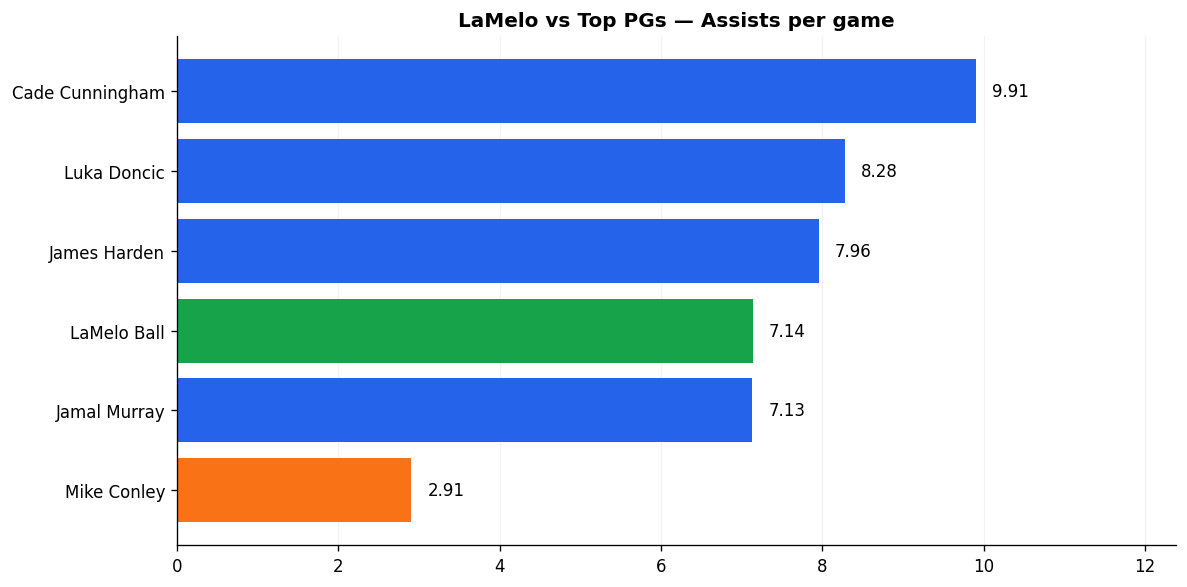

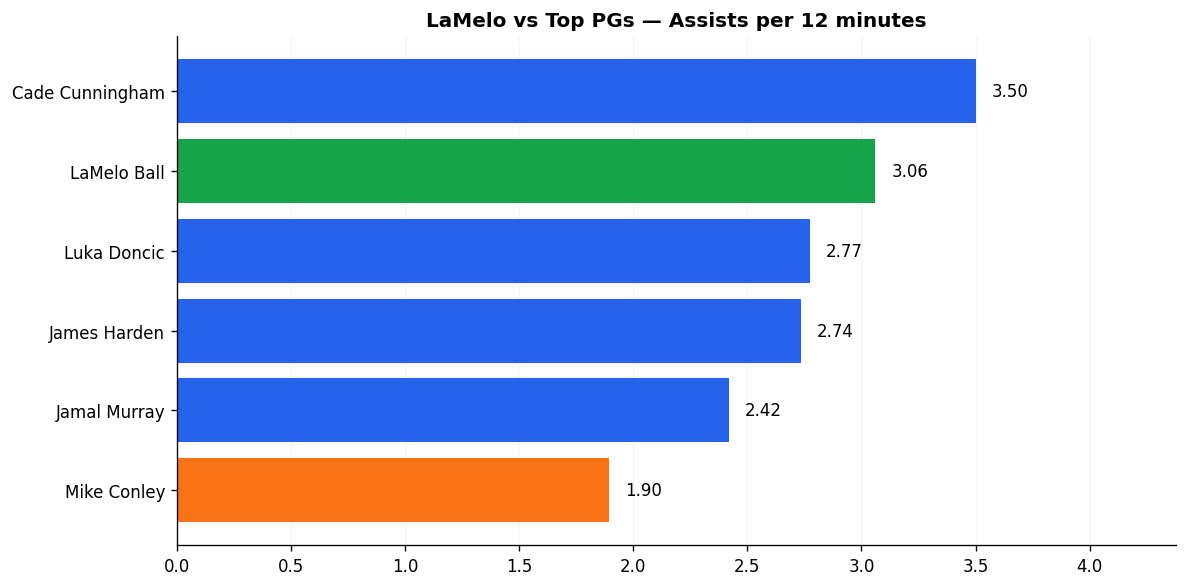

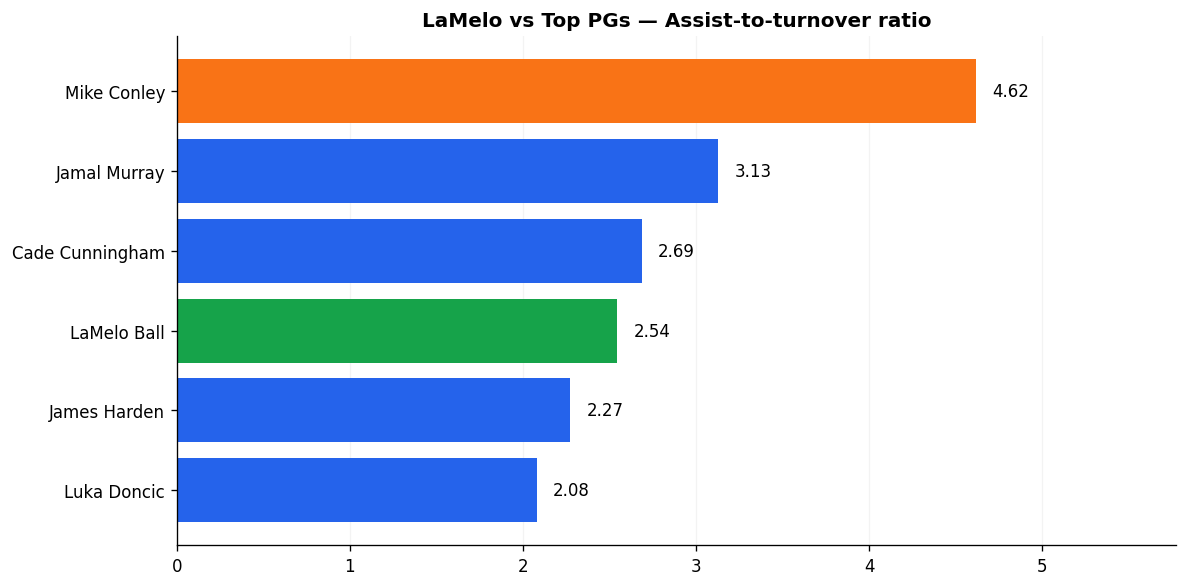

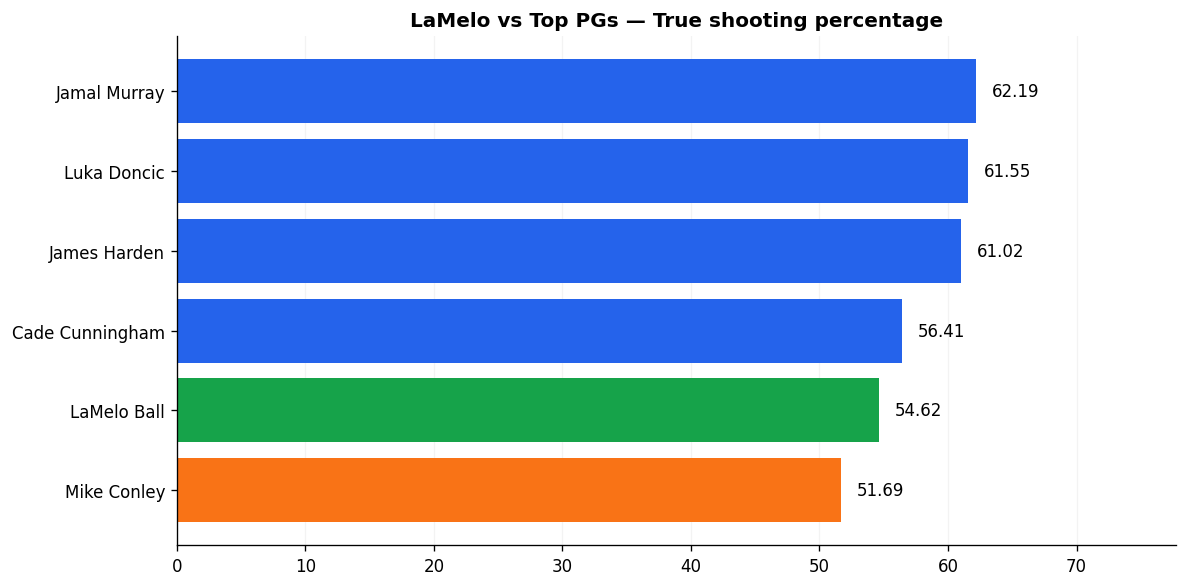


THREE-POINT SHOOTING COMPARISON


,player,GP,FG3M,FG3A,FG3M_PG,FG3A_PG,FG3_PCT,TS_PCT
317,LaMelo Ball,72,272.0,740.0,3.78,10.28,36.76,54.62
134,Luka Doncic,64,254.0,694.0,3.97,10.84,36.60,61.55
128,Donte DiVincenzo,82,244.0,644.0,2.98,7.85,37.89,56.74
508,Kon Knueppel,81,273.0,642.0,3.37,7.93,42.52,63.29
78,Derrick White,77,209.0,640.0,2.71,8.31,32.66,52.89
187,Nickeil Alexander-Walker,78,251.0,629.0,3.22,8.06,39.90,61.05
115,Donovan Mitchell,70,224.0,616.0,3.20,8.80,36.36,61.30
267,Tyrese Maxey,70,220.0,599.0,3.14,8.56,36.73,58.77
276,Toumani Camara,82,219.0,592.0,2.67,7.22,36.99,57.82
204,Collin Gillespie,80,232.0,578.0,2.90,7.22,40.14,57.48


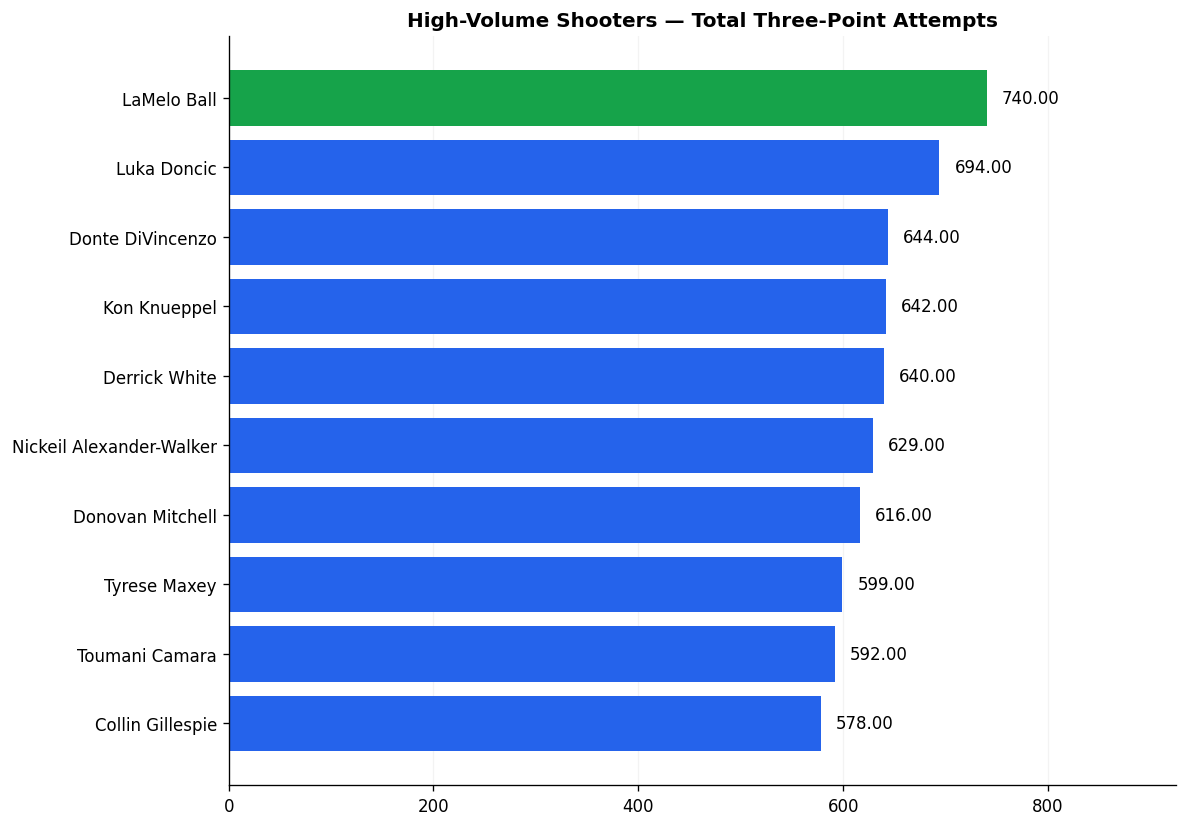

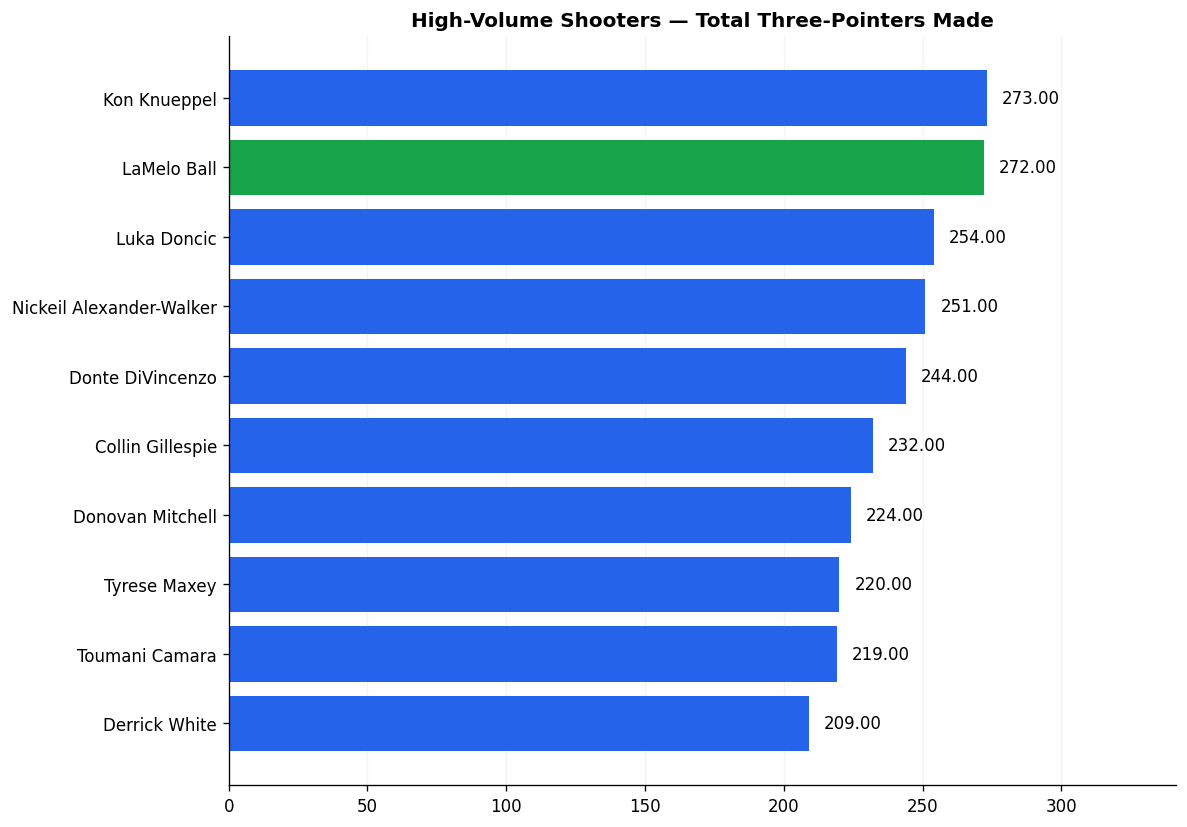

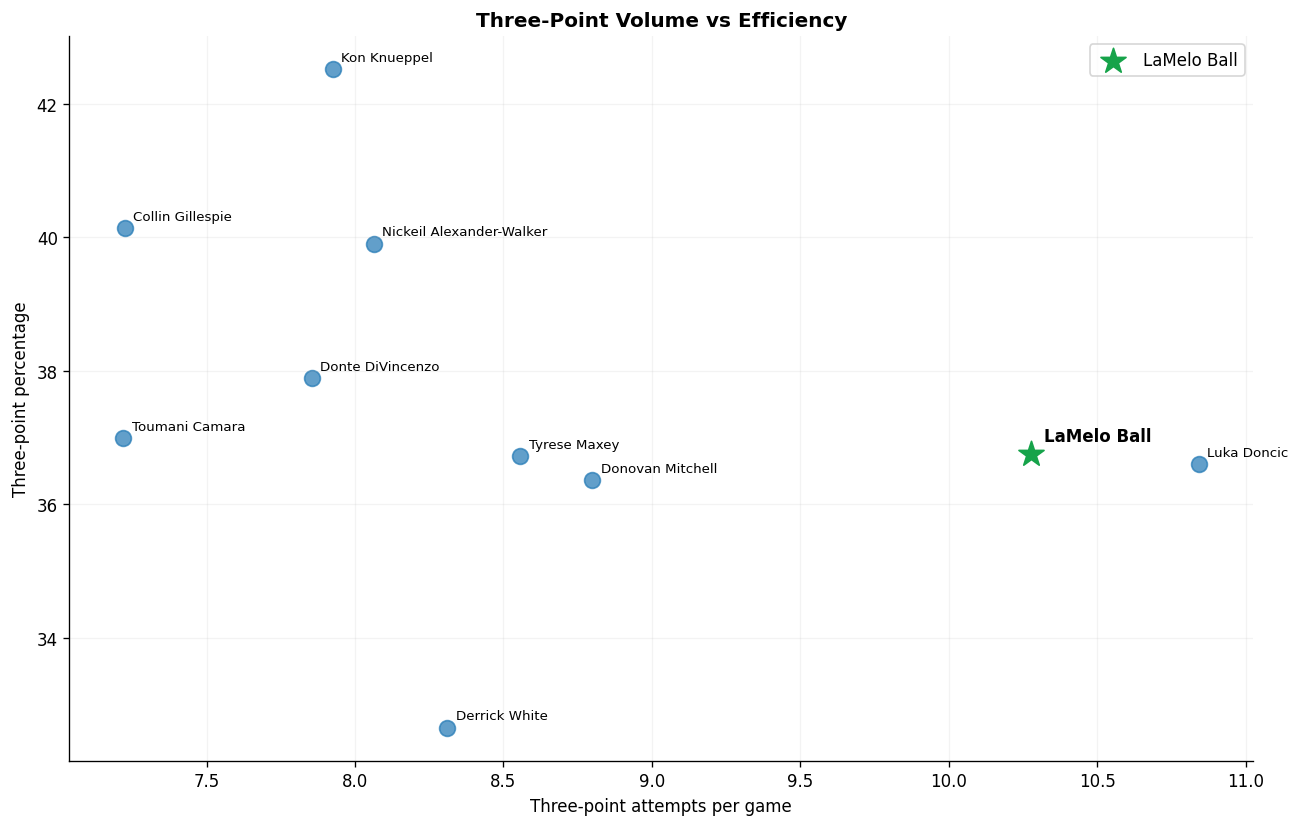


CATEGORY 3 — INITIAL ANALYSIS COMPLETE

LaMelo:
GP: 72
PPG: 20.07
APG: 7.14
AST/TO: 2.54
3PM: 272
3PA: 740
3P%: 36.76
TS%: 54.62

Output tables: /content/drive/MyDrive/minnesota_analysis/data/processed/category_3
Output charts: /content/drive/MyDrive/minnesota_analysis/figures/category_3


In [ ]:

# ============================================================
# CATEGORY 3 — LAMELO BALL
# 2025–26 REGULAR-SEASON ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE = Path("/content/drive/MyDrive/minnesota_analysis")
RAW = BASE / "data/raw/player_box_2026.parquet"

OUT = BASE / "data/processed/category_3"
FIG = BASE / "figures/category_3"

OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

assert RAW.exists(), f"Dataset not found: {RAW}"

p = pd.read_parquet(RAW)

print("Loaded:", len(p), "records")

# ------------------------------------------------------------
# 2. CLEAN REGULAR-SEASON DATA
# ------------------------------------------------------------

p = p.rename(columns={
    "athlete_display_name": "player",
    "team_abbreviation": "team"
})

p["game_id"] = p["game_id"].astype(str)

EXCLUDED_GAMES = {
    "401838140",
    "401838141",
    "401838143",
    "401809839"
}

# ESPN sometimes labels All-Star games as regular season.
# Exclude exhibition teams and known non-RS game IDs.

NBA_TEAMS = {
    "ATL", "BOS", "BKN", "CHA", "CHI", "CLE",
    "DAL", "DEN", "DET", "GS", "GSW", "HOU",
    "IND", "LAC", "LAL", "MEM", "MIA", "MIL",
    "MIN", "NO", "NOP", "NY", "NYK", "OKC",
    "ORL", "PHI", "PHX", "POR", "SAC", "SA",
    "SAS", "TOR", "UT", "UTA", "WAS", "WSH"
}

p["minutes"] = pd.to_numeric(
    p["minutes"], errors="coerce"
)

p = p[
    (p["season_type"] == 2)
    & (~p["game_id"].isin(EXCLUDED_GAMES))
    & (p["team"].isin(NBA_TEAMS))
    & (~p["did_not_play"].fillna(False).astype(bool))
    & (p["minutes"] > 0)
].copy()

numeric_cols = [
    "points", "assists", "turnovers", "rebounds",
    "minutes",
    "field_goals_made", "field_goals_attempted",
    "three_point_field_goals_made",
    "three_point_field_goals_attempted",
    "free_throws_made", "free_throws_attempted"
]

for col in numeric_cols:
    p[col] = pd.to_numeric(p[col], errors="coerce")

duplicates = p.duplicated(
    ["game_id", "athlete_id"], keep=False
)

if duplicates.any():
    display(
        p.loc[duplicates, [
            "game_id", "player", "team"
        ]]
    )
    raise ValueError("Duplicate player-game records found.")

# ------------------------------------------------------------
# 3. CALCULATE PLAYER SEASON STATISTICS
# ------------------------------------------------------------

AGG = {
    "game_id": "nunique",
    "minutes": "sum",
    "points": "sum",
    "rebounds": "sum",
    "assists": "sum",
    "turnovers": "sum",
    "field_goals_made": "sum",
    "field_goals_attempted": "sum",
    "three_point_field_goals_made": "sum",
    "three_point_field_goals_attempted": "sum",
    "free_throws_made": "sum",
    "free_throws_attempted": "sum"
}

def player_summary(df, groups):
    result = (
        df.groupby(groups, as_index=False)
        .agg(AGG)
        .rename(columns={
            "game_id": "GP",
            "minutes": "MIN",
            "points": "PTS",
            "rebounds": "REB",
            "assists": "AST",
            "turnovers": "TOV",
            "field_goals_made": "FGM",
            "field_goals_attempted": "FGA",
            "three_point_field_goals_made": "FG3M",
            "three_point_field_goals_attempted": "FG3A",
            "free_throws_made": "FTM",
            "free_throws_attempted": "FTA"
        })
    )

    result["MPG"] = result["MIN"] / result["GP"]
    result["PPG"] = result["PTS"] / result["GP"]
    result["RPG"] = result["REB"] / result["GP"]
    result["APG"] = result["AST"] / result["GP"]
    result["TOV_PG"] = result["TOV"] / result["GP"]

    result["AST_TO"] = (
        result["AST"] /
        result["TOV"].replace(0, np.nan)
    )

    result["AST_PER_12"] = (
        12 * result["AST"] /
        result["MIN"].replace(0, np.nan)
    )

    result["FG3M_PG"] = result["FG3M"] / result["GP"]
    result["FG3A_PG"] = result["FG3A"] / result["GP"]

    result["FG_PCT"] = (
        100 * result["FGM"] /
        result["FGA"].replace(0, np.nan)
    )

    result["FG3_PCT"] = (
        100 * result["FG3M"] /
        result["FG3A"].replace(0, np.nan)
    )

    result["EFG_PCT"] = (
        100 * (result["FGM"] + 0.5 * result["FG3M"]) /
        result["FGA"].replace(0, np.nan)
    )

    result["TS_PCT"] = (
        100 * result["PTS"] /
        (
            2 * (
                result["FGA"] +
                0.44 * result["FTA"]
            )
        ).replace(0, np.nan)
    )

    return result


league = player_summary(
    p, ["athlete_id", "player"]
)

team_players = player_summary(
    p, ["athlete_id", "player", "team"]
)

league.to_csv(
    OUT / "league_2026_stats.csv",
    index=False
)

# ------------------------------------------------------------
# 4. LAMELO PLAYER PROFILE
# ------------------------------------------------------------

lamelo = league[
    league["player"] == "LaMelo Ball"
].copy()

assert len(lamelo) == 1, "LaMelo record not found."

PROFILE = [
    "player", "GP", "MPG",
    "PPG", "RPG", "APG",
    "TOV_PG", "AST_TO",
    "AST_PER_12",
    "FG3M", "FG3A",
    "FG3M_PG", "FG3A_PG",
    "FG_PCT", "FG3_PCT",
    "EFG_PCT", "TS_PCT"
]

print("\nLAMELO BALL — PLAYER PROFILE")

display(
    lamelo[PROFILE].round(2)
)

lamelo[PROFILE].to_csv(
    OUT / "lamelo_profile.csv",
    index=False
)

# Confirm previously verified numbers.
assert int(lamelo.iloc[0]["GP"]) == 72
assert int(lamelo.iloc[0]["PTS"]) == 1445
assert int(lamelo.iloc[0]["FG3M"]) == 272
assert int(lamelo.iloc[0]["FG3A"]) == 740

print("LaMelo verification: PASSED")

# ------------------------------------------------------------
# 5. TOP FIVE POINT GUARD COMPARISON
# ------------------------------------------------------------

# Curated positional pool.
# Some players are PG/SG hybrids.


PG_POOL = {
    "LaMelo Ball",
    "Luka Doncic",
    "Shai Gilgeous-Alexander",
    "Trae Young",
    "Cade Cunningham",
    "Jalen Brunson",
    "Stephen Curry",
    "Ja Morant",
    "De'Aaron Fox",
    "Darius Garland",
    "James Harden",
    "Tyrese Maxey",
    "Jamal Murray",
    "Chris Paul",
    "Fred VanVleet",
    "Josh Giddey",
    "Jrue Holiday",
    "Immanuel Quickley",
    "Dejounte Murray",
    "Keyonte George",
    "Scoot Henderson",
    "Tre Jones",
    "Coby White",
    "Kyrie Irving",
    "Russell Westbrook",
    "Mike Conley",
    "Austin Reaves",
    "Brandin Podziemski",
    "Amen Thompson",
    "Tyrese Haliburton"
}

MIN_GP = 58

eligible_pg = league[
    league["player"].isin(PG_POOL)
    & (league["GP"] >= MIN_GP)
].copy()

top5_pg = (
    eligible_pg
    .sort_values("APG", ascending=False)
    .head(5)
)

# Conley: Minnesota-only statistics.
conley = team_players[
    (team_players["player"] == "Mike Conley")
    & (team_players["team"] == "MIN")
].drop(columns="team")

comparison = (
    pd.concat(
        [top5_pg, lamelo, conley],
        ignore_index=True
    )
    .drop_duplicates("player")
    .sort_values("APG", ascending=False)
)

comparison["GROUP"] = np.select(
    [
        comparison["player"] == "LaMelo Ball",
        comparison["player"] == "Mike Conley"
    ],
    ["LaMelo", "Minnesota Conley"],
    default="Top 5 PG"
)

PG_COLUMNS = [
    "player", "GROUP", "GP",
    "PPG", "APG", "AST_PER_12",
    "AST_TO", "TOV_PG",
    "MPG", "TS_PCT"
]

print("\nLAMELO VS TOP FIVE PGs")

display(
    comparison[PG_COLUMNS].round(2)
)

comparison[PG_COLUMNS].to_csv(
    OUT / "pg_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# 6. VISUALIZATION FUNCTION
# ------------------------------------------------------------

def bar_chart(df, metric, title, filename):

    data = (
        df[["player", metric]]
        .dropna()
        .sort_values(metric)
    )

    colors = [
        "#16a34a" if x == "LaMelo Ball"
        else "#f97316" if x == "Mike Conley"
        else "#2563eb"
        for x in data["player"]
    ]

    fig, ax = plt.subplots(
        figsize=(10, max(5, len(data) * 0.7))
    )

    bars = ax.barh(
        data["player"],
        data[metric],
        color=colors
    )

    maximum = data[metric].max()

    ax.set_xlim(0, maximum * 1.25)

    for bar, value in zip(bars, data[metric]):
        ax.text(
            value + maximum * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center"
        )

    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.15)
    ax.set_axisbelow(True)

    plt.tight_layout()

    plt.savefig(
        FIG / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ------------------------------------------------------------
# 7. PG PLAYMAKING CHARTS
# ------------------------------------------------------------

for metric, title in {
    "APG": "Assists per game",
    "AST_PER_12": "Assists per 12 minutes",
    "AST_TO": "Assist-to-turnover ratio",
    "TS_PCT": "True shooting percentage"
}.items():

    bar_chart(
        comparison,
        metric,
        f"LaMelo vs Top PGs — {title}",
        f"pg_{metric.lower()}.png"
    )

# ------------------------------------------------------------
# 8. THREE-POINT SHOOTING COMPARISON
# ------------------------------------------------------------

shooters = league[
    league["GP"] >= 58
].copy()

top10_volume = (
    shooters
    .sort_values("FG3A", ascending=False)
    .head(10)
)

shooting = (
    pd.concat([top10_volume, lamelo])
    .drop_duplicates("athlete_id")
    .sort_values("FG3A", ascending=False)
)

SHOOTING_COLUMNS = [
    "player", "GP",
    "FG3M", "FG3A",
    "FG3M_PG", "FG3A_PG",
    "FG3_PCT", "TS_PCT"
]

print("\nTHREE-POINT SHOOTING COMPARISON")

display(
    shooting[SHOOTING_COLUMNS].round(2)
)

shooting[SHOOTING_COLUMNS].to_csv(
    OUT / "three_point_comparison.csv",
    index=False
)

bar_chart(
    shooting,
    "FG3A",
    "High-Volume Shooters — Total Three-Point Attempts",
    "three_point_attempts.png"
)

bar_chart(
    shooting,
    "FG3M",
    "High-Volume Shooters — Total Three-Pointers Made",
    "three_point_makes.png"
)

# Volume vs efficiency scatter plot.
fig, ax = plt.subplots(figsize=(11, 7))

others = shooting[
    shooting["player"] != "LaMelo Ball"
]

ax.scatter(
    others["FG3A_PG"],
    others["FG3_PCT"],
    s=90,
    alpha=0.7
)

for _, row in others.iterrows():
    ax.annotate(
        row["player"],
        (row["FG3A_PG"], row["FG3_PCT"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

l = lamelo.iloc[0]

ax.scatter(
    l["FG3A_PG"],
    l["FG3_PCT"],
    s=250,
    color="#16a34a",
    marker="*",
    label="LaMelo Ball"
)

ax.annotate(
    "LaMelo Ball",
    (l["FG3A_PG"], l["FG3_PCT"]),
    xytext=(8, 8),
    textcoords="offset points",
    fontweight="bold"
)

ax.set_xlabel("Three-point attempts per game")
ax.set_ylabel("Three-point percentage")
ax.set_title(
    "Three-Point Volume vs Efficiency",
    fontweight="bold"
)
ax.grid(alpha=0.15)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG / "three_point_volume_efficiency.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("CATEGORY 3 — INITIAL ANALYSIS COMPLETE")
print("=" * 55)

print("\nLaMelo:")
print("GP:", int(l["GP"]))
print("PPG:", round(l["PPG"], 2))
print("APG:", round(l["APG"], 2))
print("AST/TO:", round(l["AST_TO"], 2))
print("3PM:", int(l["FG3M"]))
print("3PA:", int(l["FG3A"]))
print("3P%:", round(l["FG3_PCT"], 2))
print("TS%:", round(l["TS_PCT"], 2))

print("\nOutput tables:", OUT)
print("Output charts:", FIG)

Original ESPN records: 34883
Cleaned regular-season records: 25735

LAMELO BALL — 2025–26 PLAYER PROFILE


,player,GP,MPG,PPG,RPG,APG,TOV_PG,AST_TO,AST_PER_12,FG3M,FG3A,FG3M_PG,FG3A_PG,FG_PCT,FG3_PCT,EFG_PCT,TS_PCT
317,LaMelo Ball,72,27.99,20.07,4.82,7.14,2.81,2.54,3.06,272.0,740.0,3.78,10.28,40.68,36.76,51.61,54.62



ESPN BOX-SCORE COMPARISON


,player,GP,PPG,APG,AST_PER_12,AST_TO,TOV_PG,TS_PCT
0,LaMelo Ball,72,20.07,7.14,3.06,2.54,2.81,54.62
1,Cade Cunningham,64,23.92,9.91,3.50,2.69,3.69,56.41
2,Luka Doncic,64,33.48,8.28,2.77,2.08,3.98,61.55
3,James Harden,70,23.60,7.96,2.74,2.27,3.50,61.02
4,Jalen Brunson,74,26.04,6.80,2.33,2.87,2.36,58.03
5,Trae Young,15,17.93,8.00,3.77,3.08,2.60,61.23
6,Mike Conley,54,4.54,2.91,1.90,4.62,0.63,51.69



NBA PASSING TRACKING


...


NBA DRIVES TRACKING


,player,GP,MPG,DRIVES,DRIVES_PER_12,DRIVE_PTS,DRIVE_PASS,DRIVE_AST,AST_PER_100_DRIVES,DRIVE_TOV
0,LaMelo Ball,72,28.0,13.4,5.74,6.4,5.8,1.8,13.43,0.8
1,Cade Cunningham,64,33.9,22.2,7.86,11.9,9.9,2.8,12.61,1.1
2,Luka Doncic,64,35.8,18.9,6.34,13.2,6.8,1.8,9.52,1.0
3,James Harden,70,34.8,17.2,5.93,10.1,7.1,2.0,11.63,1.1
4,Jalen Brunson,74,35.0,20.2,6.93,13.0,7.3,1.6,7.92,0.8



PULL-UP SHOOTING COMPARISON


,player,PULLUP_FGA,PULLUP_FG_PCT,PULLUP_3PA,PULLUP_3PM,PULLUP_3P_PCT,PULLUP_EFG_PCT
0,LaMelo Ball,7.4,36.6,5.6,2.1,36.8,50.5
1,Cade Cunningham,7.4,41.4,3.4,1.2,34.7,49.4
2,Luka Doncic,13.1,42.2,7.5,2.7,36.3,52.6
3,James Harden,8.0,37.8,6.0,2.2,36.3,51.5
4,Jalen Brunson,9.9,44.1,4.1,1.5,35.6,51.5



SECTION A — PLAYMAKING


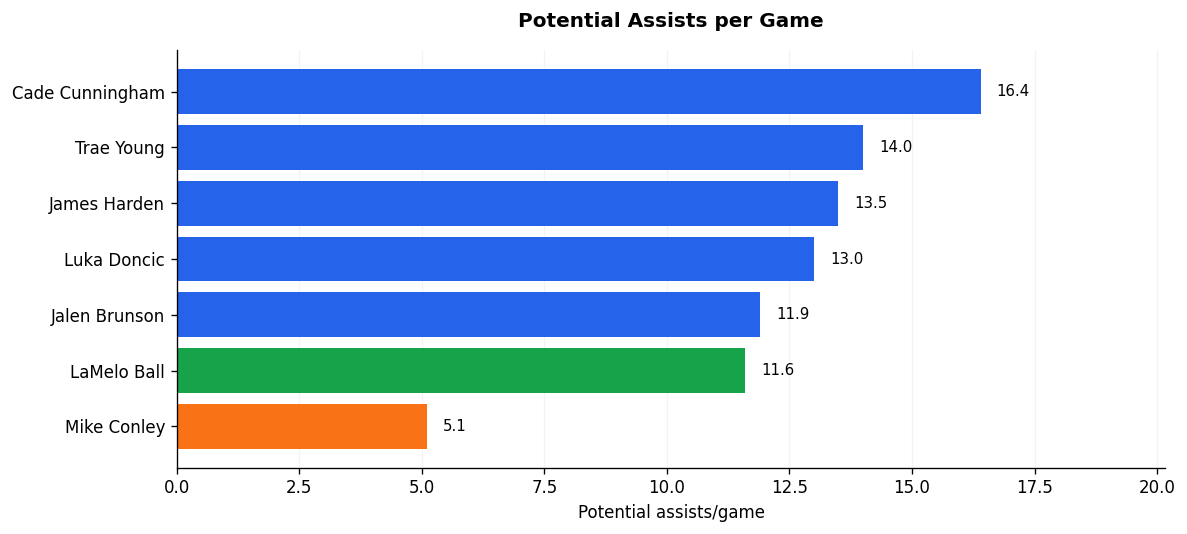

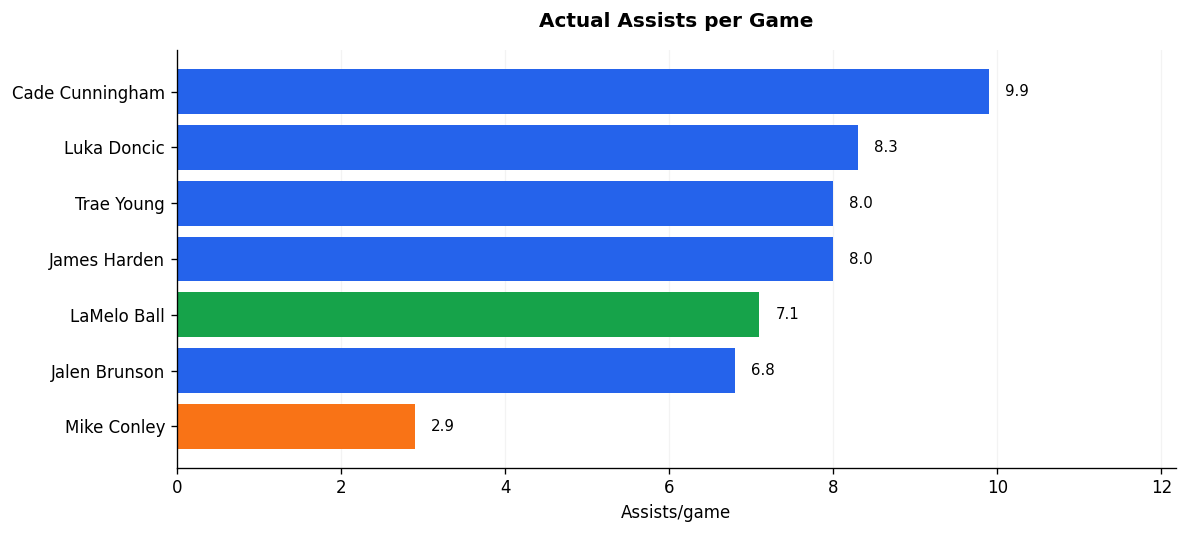

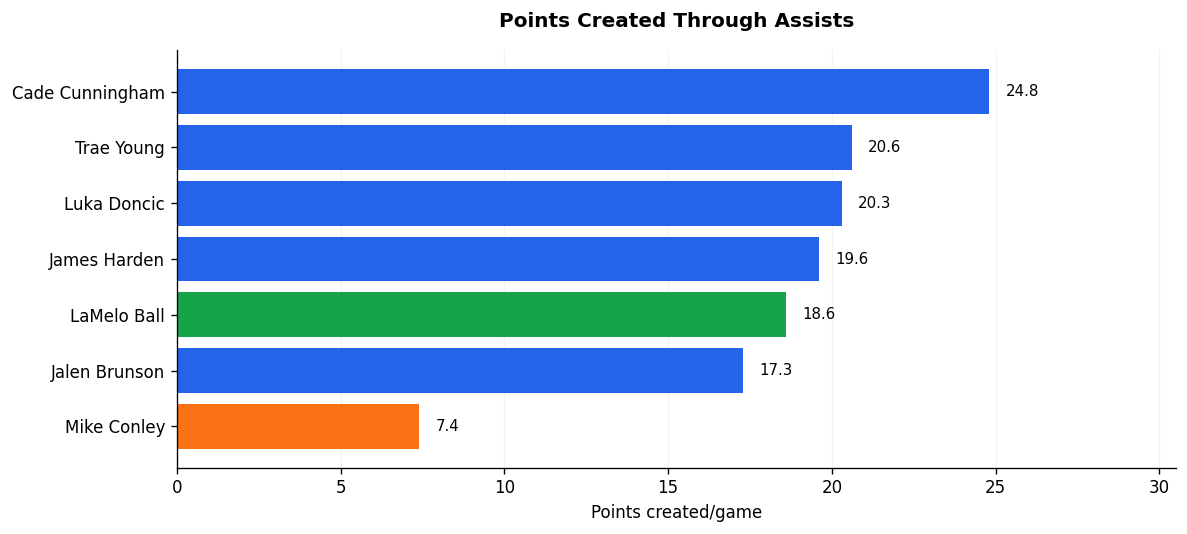

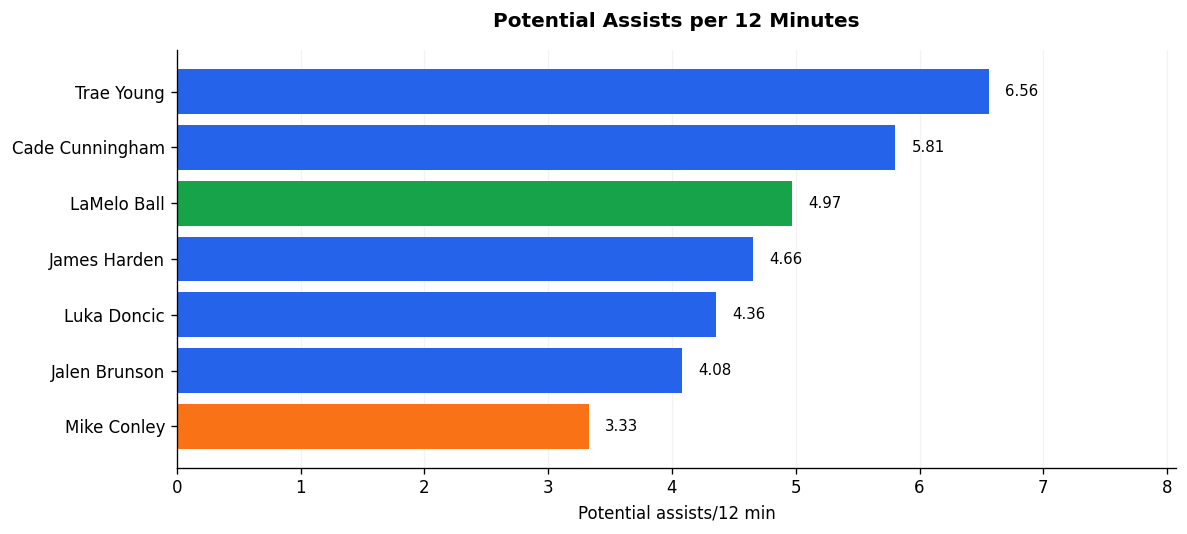

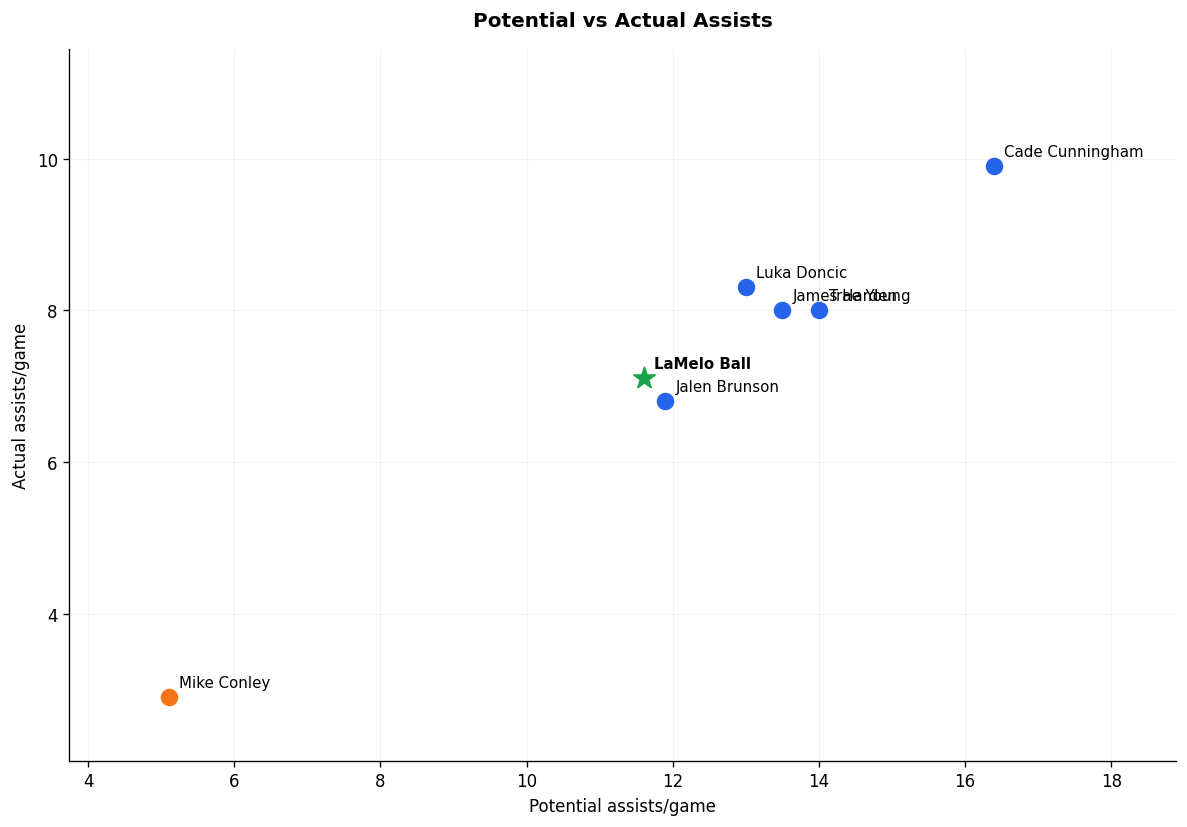

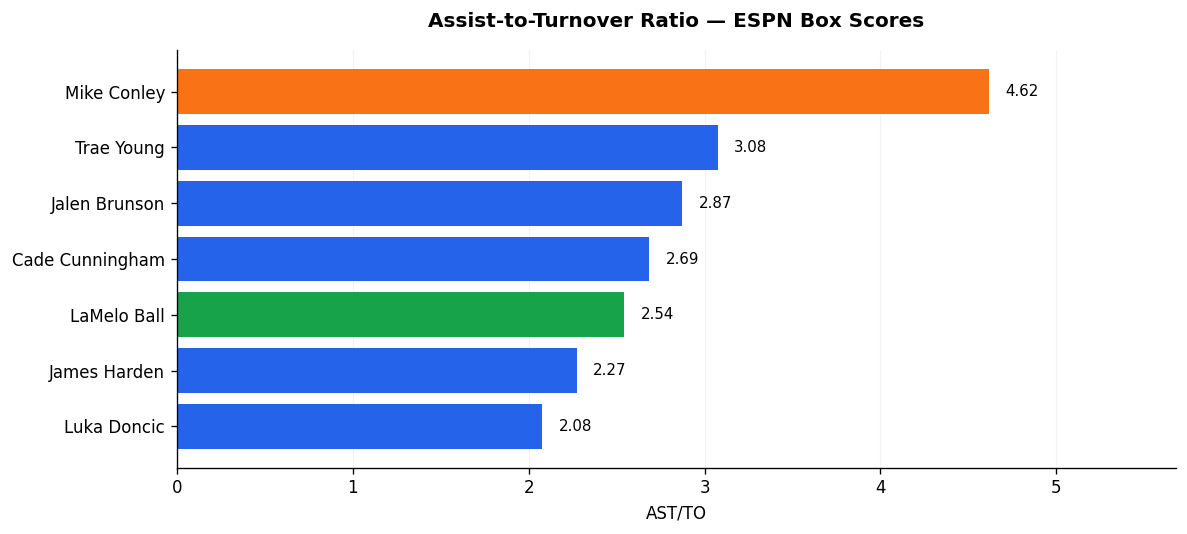


SECTION B — DRIVING AND PENETRATION


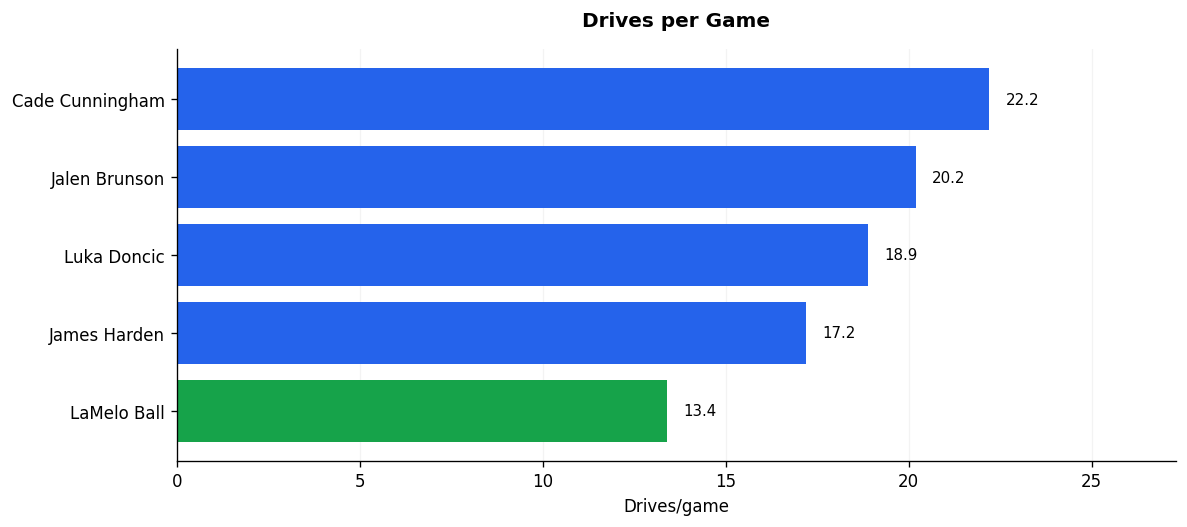

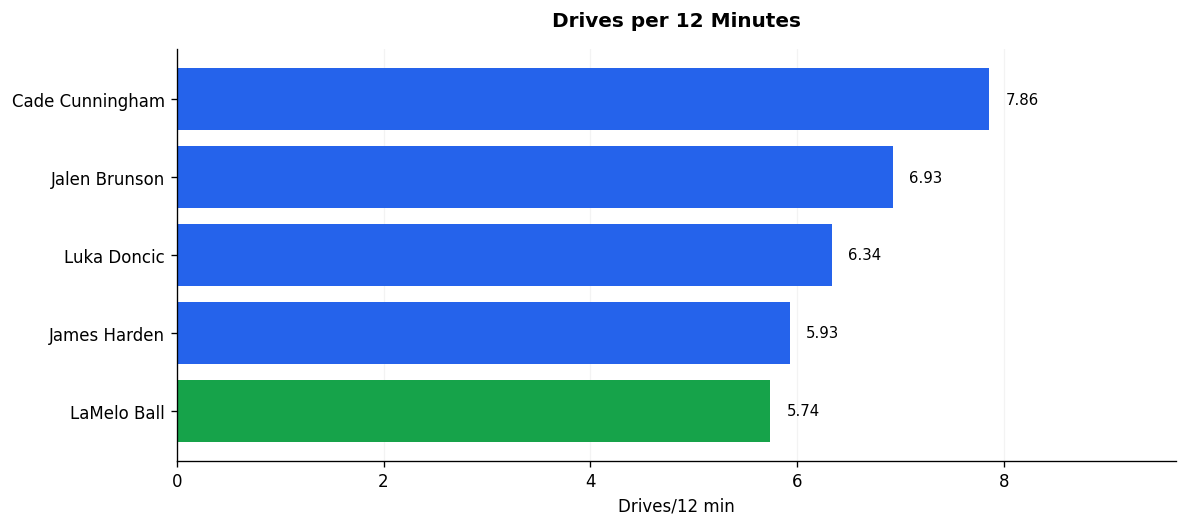

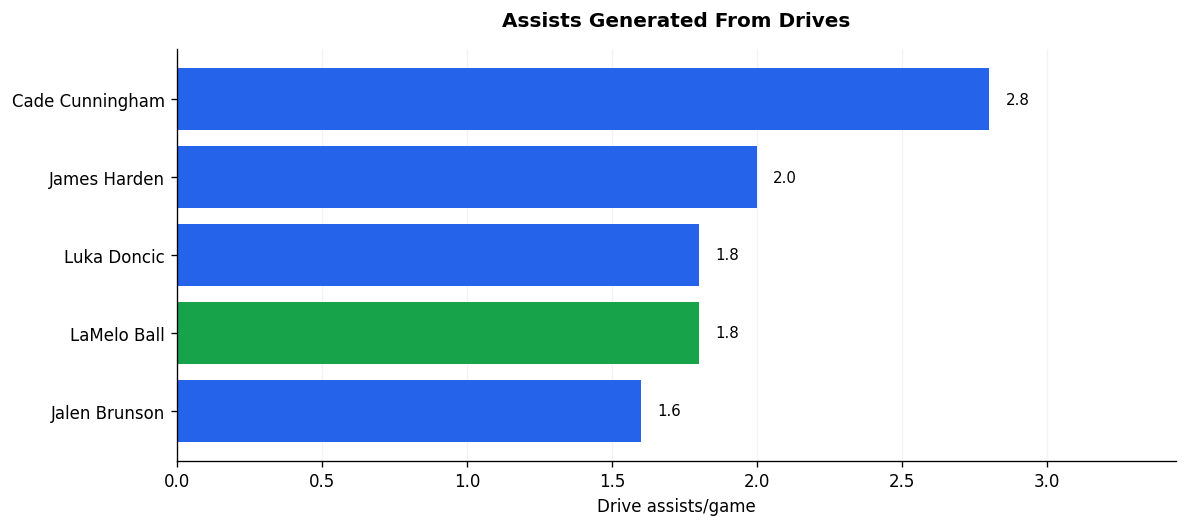

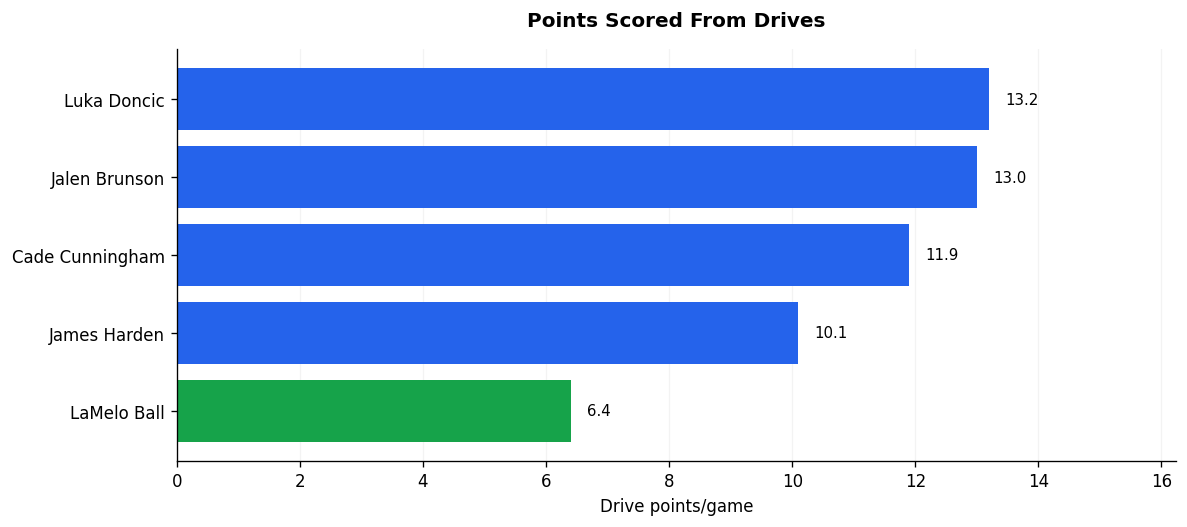

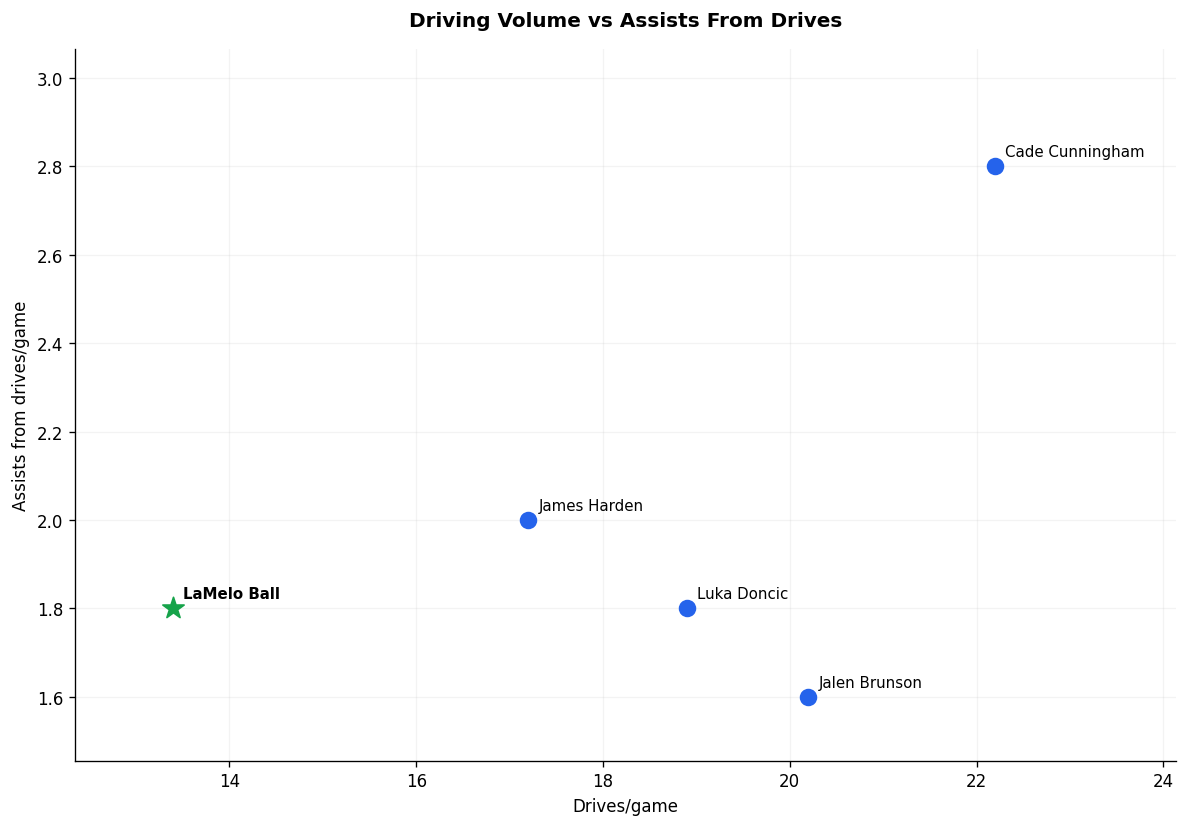


SECTION C — THREE-POINT SHOOTING

TOP THREE-POINT MAKERS


,player,GP,FG3M,FG3A,FG3_PCT
508,Kon Knueppel,81,273.0,642.0,42.52
317,LaMelo Ball,72,272.0,740.0,36.76
134,Luka Doncic,64,254.0,694.0,36.60
187,Nickeil Alexander-Walker,78,251.0,629.0,39.90
133,Jamal Murray,75,245.0,563.0,43.52
128,Donte DiVincenzo,82,244.0,644.0,37.89
254,AJ Green,78,232.0,554.0,41.88
204,Collin Gillespie,80,232.0,578.0,40.14
463,Reed Sheppard,82,227.0,576.0,39.41
115,Donovan Mitchell,70,224.0,616.0,36.36



TOP THREE-POINT ATTEMPT VOLUME


,player,GP,FG3M,FG3A,FG3A_PG,FG3_PCT
317,LaMelo Ball,72,272.0,740.0,10.28,36.76
134,Luka Doncic,64,254.0,694.0,10.84,36.60
128,Donte DiVincenzo,82,244.0,644.0,7.85,37.89
508,Kon Knueppel,81,273.0,642.0,7.93,42.52
78,Derrick White,77,209.0,640.0,8.31,32.66
187,Nickeil Alexander-Walker,78,251.0,629.0,8.06,39.90
115,Donovan Mitchell,70,224.0,616.0,8.80,36.36
267,Tyrese Maxey,70,220.0,599.0,8.56,36.73
276,Toumani Camara,82,219.0,592.0,7.22,36.99
204,Collin Gillespie,80,232.0,578.0,7.22,40.14


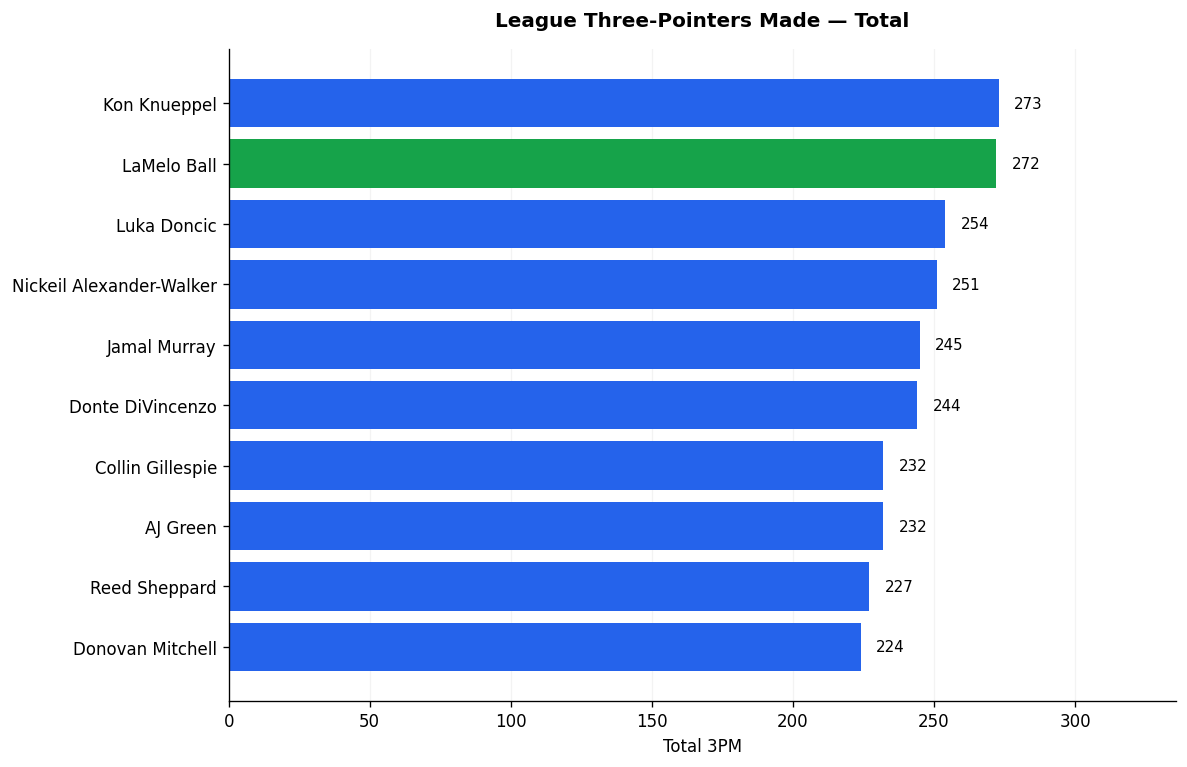

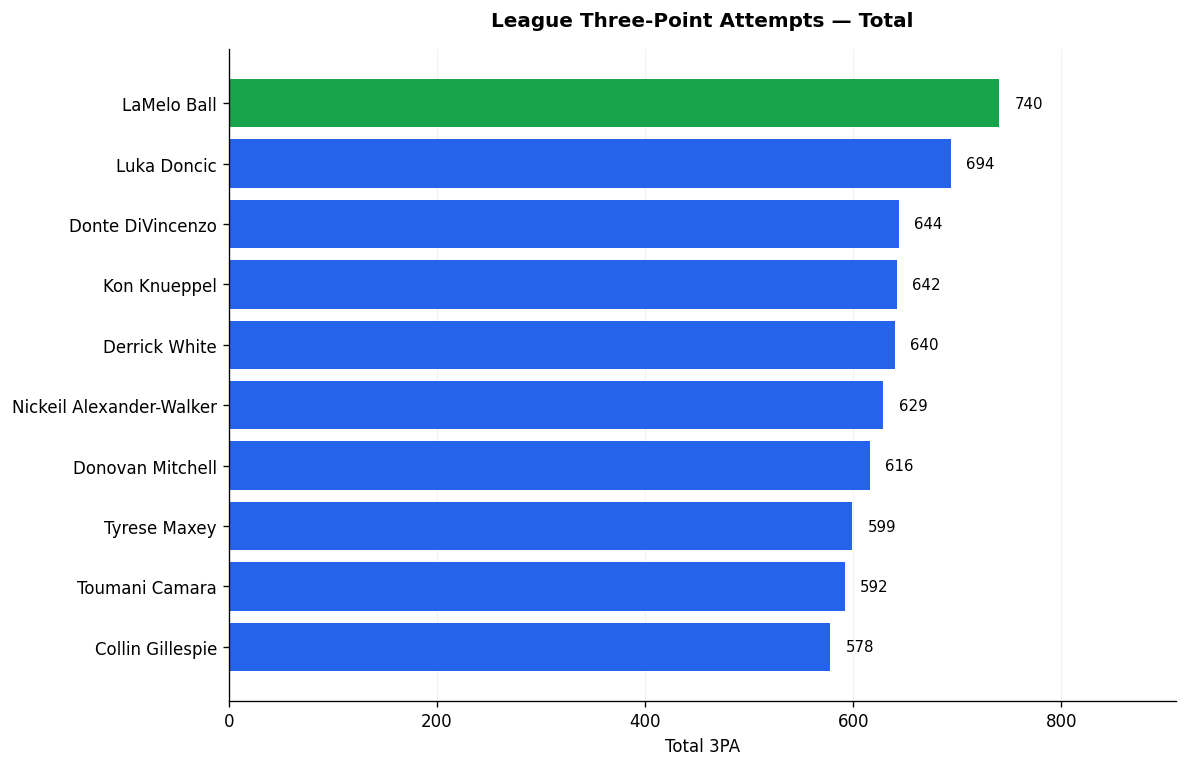

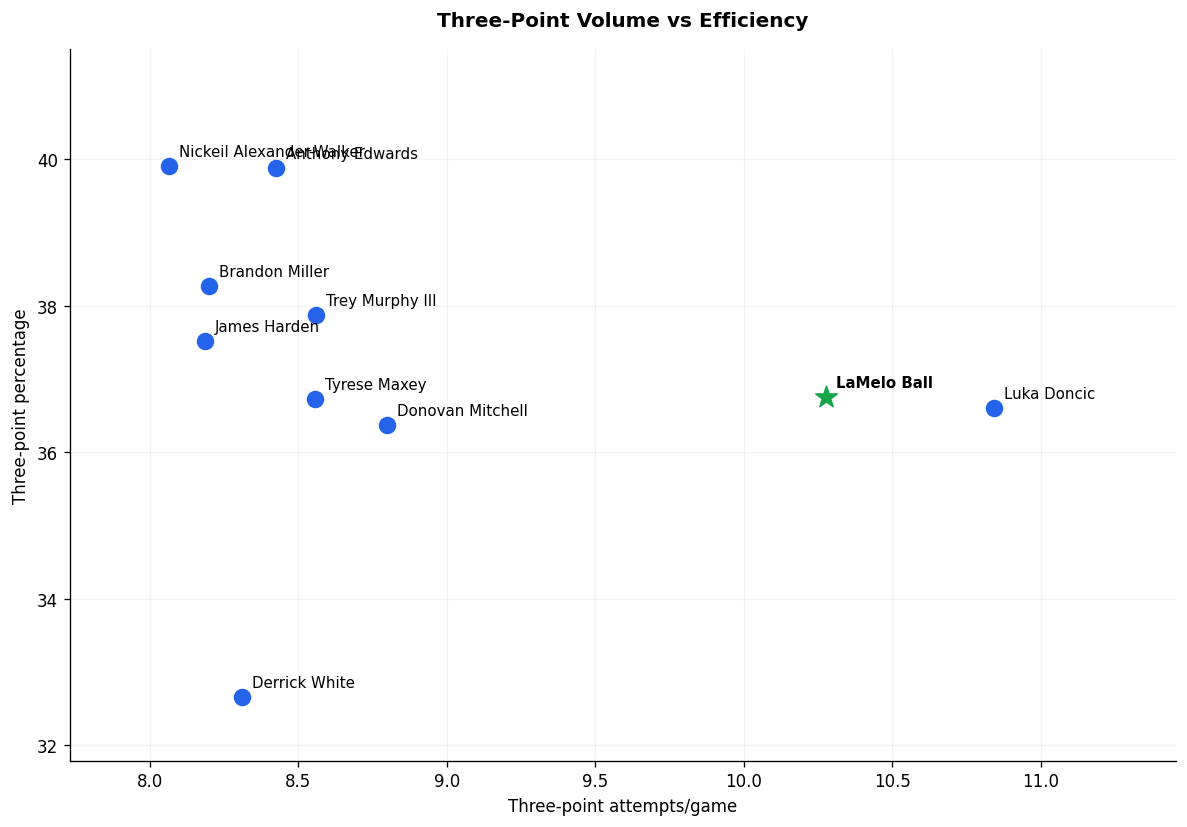


SECTION D — PULL-UP SHOOTING


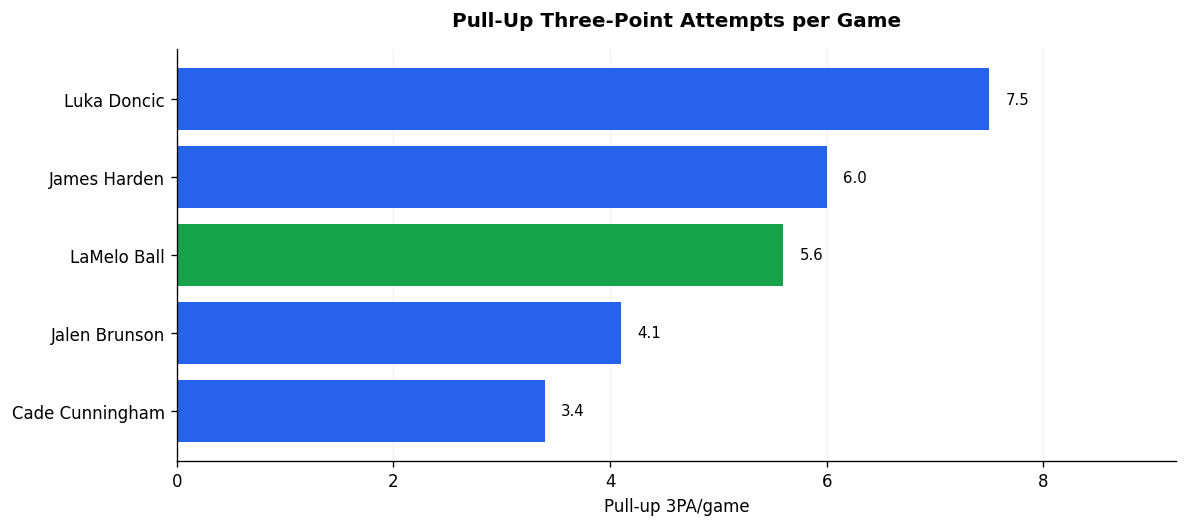

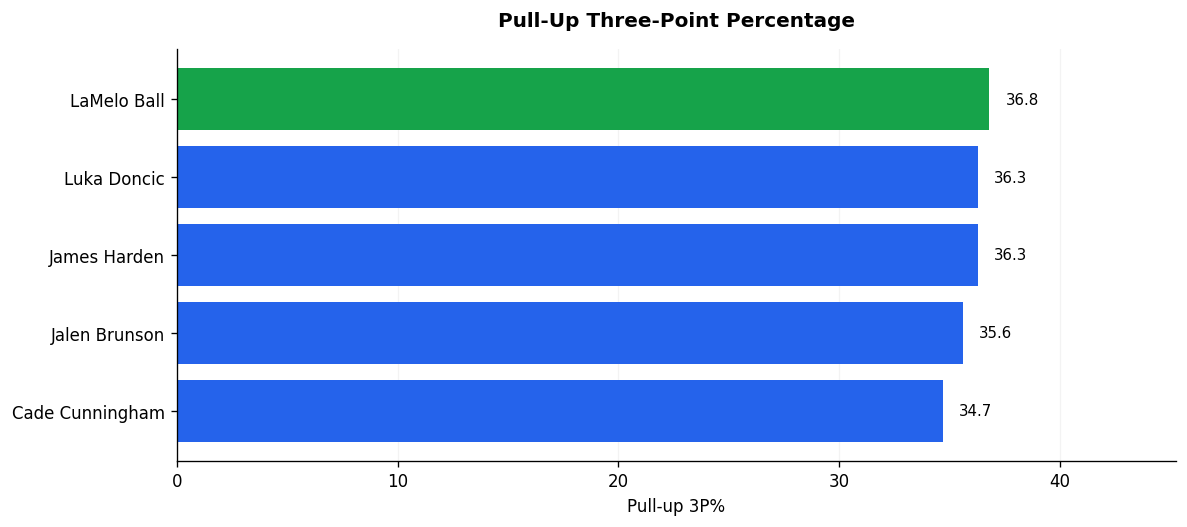

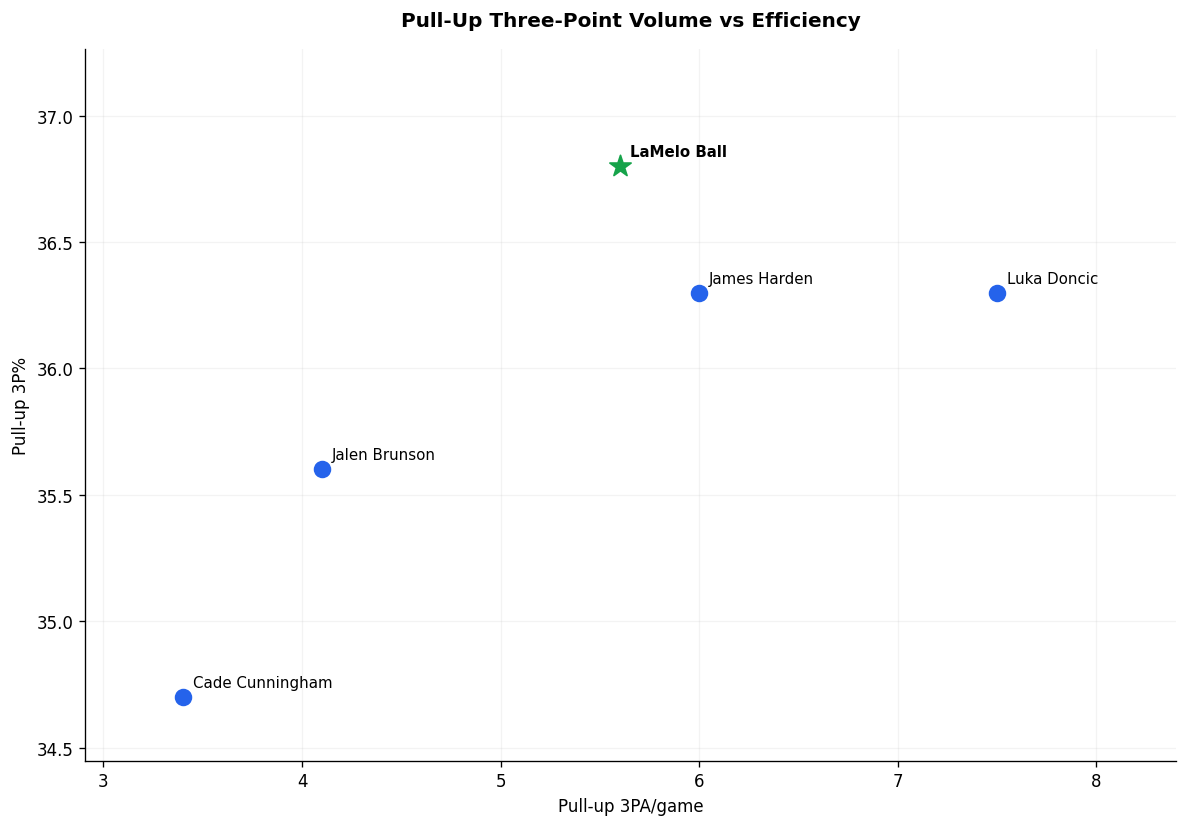


LAMELO — PULL-UP THREE-POINT PROFILE
Total 3PA/game: 10.28
Pull-up 3PA/game: 5.6
Pull-up 3P%: 36.8
Approximate pull-up share of all 3PA: 54.5 %

CATEGORY 3 — MASTER COMPARISON


,player,GP,MPG,PPG,RPG,APG,TOV_PG,AST_TO,FG3M,FG3A,...,AST_PTS_CREATED,SECONDARY_AST,DRIVES,DRIVES_PER_12,DRIVE_PTS,DRIVE_AST,DRIVE_TOV,PULLUP_3PA,PULLUP_3PM,PULLUP_3P_PCT
0,LaMelo Ball,72,27.99,20.07,4.82,7.14,2.81,2.54,272.0,740.0,...,18.6,1.1,13.4,5.74,6.4,1.8,0.8,5.6,2.1,36.8
1,Cade Cunningham,64,33.94,23.92,5.55,9.91,3.69,2.69,125.0,366.0,...,24.8,1.3,22.2,7.86,11.9,2.8,1.1,3.4,1.2,34.7
2,Luka Doncic,64,35.83,33.48,7.73,8.28,3.98,2.08,254.0,694.0,...,20.3,1.6,18.9,6.34,13.2,1.8,1.0,7.5,2.7,36.3
3,James Harden,70,34.90,23.60,4.80,7.96,3.50,2.27,215.0,573.0,...,19.6,1.2,17.2,5.93,10.1,2.0,1.1,6.0,2.2,36.3
4,Jalen Brunson,74,35.08,26.04,3.34,6.80,2.36,2.87,195.0,528.0,...,17.3,1.5,20.2,6.93,13.0,1.6,0.8,4.1,1.5,35.6
5,Trae Young,15,25.47,17.93,2.00,8.00,2.60,3.08,27.0,80.0,...,20.6,1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Mike Conley,54,18.41,4.54,1.72,2.91,0.63,4.62,56.0,166.0,...,7.4,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



VALIDATION
LaMelo ESPN verification: PASSED
LaMelo passing verification: PASSED
LaMelo drives verification: PASSED
LaMelo pull-up verification: PASSED
Master table duplicate check: PASSED

CATEGORY 3 — ANALYSIS COMPLETE

LaMelo's box-score statistics
GP: 72
PPG: 20.07
APG: 7.14
AST/TO: 2.54
3PM: 272
3PA: 740
3P%: 36.76
TS%: 54.62

LaMelo's tracking statistics
Potential AST/game: 11.6
AST points created/game: 18.6
Drives/game: 13.4
Assists from drives/game: 1.8
Pull-up 3PA/game: 5.6
Pull-up 3P%: 36.8

CSV output: /content/drive/MyDrive/minnesota_analysis/data/processed/category_3_final
Chart output: /content/drive/MyDrive/minnesota_analysis/figures/category_3_final

Generated charts:
 - 01_potential_assists.png
 - 02_actual_assists.png
 - 03_assist_points_created.png
 - 04_potential_assists_per_12.png
 - 05_potential_vs_actual_assists.png
 - 06_assist_turnover_ratio.png
 - 07_drives_per_game.png
 - 08_drives_per_12.png
 - 09_drive_assists.png
 - 10_drive_points.png
 - 11_drives_vs_driv

In [ ]:

# ============================================================
# CATEGORY 3 — LAMELO BALL
# PLAYMAKING, THREE-POINT SHOOTING & OFFENSIVE CREATION
# 2025–26 REGULAR SEASON
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# 1. PATHS AND CONFIGURATION
# ============================================================

BASE = Path("/content/drive/MyDrive/minnesota_analysis")

RAW = BASE / "data/raw/player_box_2026.parquet"

OUT = BASE / "data/processed/category_3_final"
FIG = BASE / "figures/category_3_final"

OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

assert RAW.exists(), (
    f"Missing dataset: {RAW}\n"
    "Check that Google Drive is mounted."
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10
})

# Display colors
LAMELO_COLOR = "#16a34a"
CONLEY_COLOR = "#f97316"
PEER_COLOR = "#2563eb"

def player_color(name):
    if name == "LaMelo Ball":
        return LAMELO_COLOR
    if name == "Mike Conley":
        return CONLEY_COLOR
    return PEER_COLOR

# ============================================================
# 2. LOAD AND CLEAN ESPN DATA
# ============================================================

raw = pd.read_parquet(RAW)

print("Original ESPN records:", len(raw))

p = raw.rename(columns={
    "athlete_display_name": "player",
    "team_abbreviation": "team"
}).copy()

p["game_id"] = p["game_id"].astype(str)

p["season_type"] = pd.to_numeric(
    p["season_type"],
    errors="coerce"
)

EXCLUDED_GAMES = {
    "401838140",  # All-Star
    "401838141",  # All-Star
    "401838143",  # All-Star
    "401809839"   # NBA Cup final
}

NBA_TEAMS = {
    "ATL", "BOS", "BKN", "CHA", "CHI", "CLE",
    "DAL", "DEN", "DET", "GS", "GSW", "HOU",
    "IND", "LAC", "LAL", "MEM", "MIA", "MIL",
    "MIN", "NO", "NOP", "NY", "NYK", "OKC",
    "ORL", "PHI", "PHX", "POR", "SAC", "SA",
    "SAS", "TOR", "UT", "UTA", "WAS", "WSH"
}

def parse_minutes(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str) and ":" in value:
        minutes, seconds = value.split(":", 1)
        return float(minutes) + float(seconds) / 60

    return pd.to_numeric(value, errors="coerce")

p["minutes"] = p["minutes"].apply(parse_minutes)

NUMERIC_COLUMNS = [
    "points",
    "rebounds",
    "assists",
    "turnovers",
    "field_goals_made",
    "field_goals_attempted",
    "three_point_field_goals_made",
    "three_point_field_goals_attempted",
    "free_throws_made",
    "free_throws_attempted"
]

for col in NUMERIC_COLUMNS:
    p[col] = pd.to_numeric(p[col], errors="coerce")

p = p[
    (p["season_type"] == 2)
    & (~p["game_id"].isin(EXCLUDED_GAMES))
    & (p["team"].isin(NBA_TEAMS))
    & (~p["did_not_play"].fillna(False).astype(bool))
    & (p["minutes"] > 0)
].copy()

# Avoid silently double-counting games.
duplicate_mask = p.duplicated(
    ["game_id", "athlete_id"],
    keep=False
)

if duplicate_mask.any():
    display(
        p.loc[
            duplicate_mask,
            ["game_id", "player", "team"]
        ]
    )

    raise ValueError(
        "Duplicate player-game records detected."
    )

print("Cleaned regular-season records:", len(p))

# ============================================================
# 3. CALCULATE PLAYER STATISTICS
# ============================================================

AGGREGATIONS = {
    "game_id": "nunique",
    "minutes": "sum",
    "points": "sum",
    "rebounds": "sum",
    "assists": "sum",
    "turnovers": "sum",
    "field_goals_made": "sum",
    "field_goals_attempted": "sum",
    "three_point_field_goals_made": "sum",
    "three_point_field_goals_attempted": "sum",
    "free_throws_made": "sum",
    "free_throws_attempted": "sum"
}

def aggregate_players(data, groups):

    result = (
        data.groupby(groups, as_index=False)
        .agg(AGGREGATIONS)
        .rename(columns={
            "game_id": "GP",
            "minutes": "MIN",
            "points": "PTS",
            "rebounds": "REB",
            "assists": "AST",
            "turnovers": "TOV",
            "field_goals_made": "FGM",
            "field_goals_attempted": "FGA",
            "three_point_field_goals_made": "FG3M",
            "three_point_field_goals_attempted": "FG3A",
            "free_throws_made": "FTM",
            "free_throws_attempted": "FTA"
        })
    )

    result["MPG"] = result["MIN"] / result["GP"]
    result["PPG"] = result["PTS"] / result["GP"]
    result["RPG"] = result["REB"] / result["GP"]
    result["APG"] = result["AST"] / result["GP"]
    result["TOV_PG"] = result["TOV"] / result["GP"]

    result["AST_TO"] = (
        result["AST"]
        / result["TOV"].replace(0, np.nan)
    )

    result["AST_PER_12"] = (
        12 * result["AST"]
        / result["MIN"].replace(0, np.nan)
    )

    result["FG3M_PG"] = result["FG3M"] / result["GP"]
    result["FG3A_PG"] = result["FG3A"] / result["GP"]

    result["FG_PCT"] = (
        100 * result["FGM"]
        / result["FGA"].replace(0, np.nan)
    )

    result["FG3_PCT"] = (
        100 * result["FG3M"]
        / result["FG3A"].replace(0, np.nan)
    )

    result["EFG_PCT"] = (
        100 * (
            result["FGM"] + 0.5 * result["FG3M"]
        )
        / result["FGA"].replace(0, np.nan)
    )

    result["TS_PCT"] = (
        100 * result["PTS"]
        / (
            2 * (
                result["FGA"]
                + 0.44 * result["FTA"]
            )
        ).replace(0, np.nan)
    )

    return result


# Full-season totals across teams
league = aggregate_players(
    p,
    ["athlete_id", "player"]
)

# Team-specific totals
team_players = aggregate_players(
    p,
    ["athlete_id", "player", "team"]
)

league.to_csv(
    OUT / "league_player_statistics.csv",
    index=False
)

# ============================================================
# 4. LAMELO PLAYER PROFILE
# ============================================================

lamelo = league[
    league["player"] == "LaMelo Ball"
].copy()

assert len(lamelo) == 1

l = lamelo.iloc[0]

# Verify against the previously checked raw data.
assert int(l["GP"]) == 72
assert int(l["PTS"]) == 1445
assert int(l["FG3M"]) == 272
assert int(l["FG3A"]) == 740

PROFILE_COLUMNS = [
    "player",
    "GP",
    "MPG",
    "PPG",
    "RPG",
    "APG",
    "TOV_PG",
    "AST_TO",
    "AST_PER_12",
    "FG3M",
    "FG3A",
    "FG3M_PG",
    "FG3A_PG",
    "FG_PCT",
    "FG3_PCT",
    "EFG_PCT",
    "TS_PCT"
]

print("\n" + "=" * 65)
print("LAMELO BALL — 2025–26 PLAYER PROFILE")
print("=" * 65)

display(
    lamelo[PROFILE_COLUMNS].round(2)
)

lamelo[PROFILE_COLUMNS].to_csv(
    OUT / "lamelo_player_profile.csv",
    index=False
)

# ============================================================
# 5. DEFINE THE COMPARISON GROUP
# ============================================================


PEERS = [
    "Cade Cunningham",
    "Luka Doncic",
    "James Harden",
    "Jalen Brunson",
    "Trae Young"
]

ALL_COMPARISON_PLAYERS = [
    "LaMelo Ball",
    *PEERS,
    "Mike Conley"
]

# Minnesota-specific Conley statistics.
conley = team_players[
    (team_players["player"] == "Mike Conley")
    & (team_players["team"] == "MIN")
].drop(columns="team")

# Full-season ESPN data for all comparison guards.
peer_box = league[
    league["player"].isin(
        ["LaMelo Ball", *PEERS]
    )
].copy()

comparison_box = pd.concat(
    [peer_box, conley],
    ignore_index=True
)

comparison_box = comparison_box[
    comparison_box["player"].isin(
        ALL_COMPARISON_PLAYERS
    )
]

comparison_box["player"] = pd.Categorical(
    comparison_box["player"],
    categories=ALL_COMPARISON_PLAYERS,
    ordered=True
)

comparison_box = (
    comparison_box
    .sort_values("player")
    .reset_index(drop=True)
)

comparison_box["player"] = (
    comparison_box["player"].astype(str)
)

print("\nESPN BOX-SCORE COMPARISON")

display(
    comparison_box[[
        "player",
        "GP",
        "PPG",
        "APG",
        "AST_PER_12",
        "AST_TO",
        "TOV_PG",
        "TS_PCT"
    ]].round(2)
)

comparison_box.to_csv(
    OUT / "pg_box_score_comparison.csv",
    index=False
)

# ============================================================
# 6. NBA PASSING TRACKING

# ============================================================



passing = pd.DataFrame([
    {
        "player": "LaMelo Ball",
        "TRACK_TEAM": "CHA",
        "TRACK_GP": 72,
        "TRACK_MPG": 28.0,
        "PASSES_MADE": 48.8,
        "PASSES_RECEIVED": 70.6,
        "TRACK_AST": 7.1,
        "SECONDARY_AST": 1.1,
        "POT_AST": 11.6,
        "AST_PTS_CREATED": 18.6,
        "AST_ADJ": 8.8,
        "AST_TO_PASS_PCT": 14.6
    },
    {
        "player": "Cade Cunningham",
        "TRACK_TEAM": "DET",
        "TRACK_GP": 64,
        "TRACK_MPG": 33.9,
        "PASSES_MADE": 60.0,
        "PASSES_RECEIVED": 86.3,
        "TRACK_AST": 9.9,
        "SECONDARY_AST": 1.3,
        "POT_AST": 16.4,
        "AST_PTS_CREATED": 24.8,
        "AST_ADJ": 12.4,
        "AST_TO_PASS_PCT": 16.5
    },
    {
        "player": "Luka Doncic",
        "TRACK_TEAM": "LAL",
        "TRACK_GP": 64,
        "TRACK_MPG": 35.8,
        "PASSES_MADE": 53.0,
        "PASSES_RECEIVED": 79.7,
        "TRACK_AST": 8.3,
        "SECONDARY_AST": 1.6,
        "POT_AST": 13.0,
        "AST_PTS_CREATED": 20.3,
        "AST_ADJ": 10.7,
        "AST_TO_PASS_PCT": 15.6
    },
    {
        "player": "James Harden",
        "TRACK_TEAM": "CLE",
        "TRACK_GP": 70,
        "TRACK_MPG": 34.8,
        "PASSES_MADE": 50.7,
        "PASSES_RECEIVED": 77.2,
        "TRACK_AST": 8.0,
        "SECONDARY_AST": 1.2,
        "POT_AST": 13.5,
        "AST_PTS_CREATED": 19.6,
        "AST_ADJ": 9.7,
        "AST_TO_PASS_PCT": 15.7
    },
    {
        "player": "Jalen Brunson",
        "TRACK_TEAM": "NYK",
        "TRACK_GP": 74,
        "TRACK_MPG": 35.0,
        "PASSES_MADE": 63.1,
        "PASSES_RECEIVED": 89.0,
        "TRACK_AST": 6.8,
        "SECONDARY_AST": 1.5,
        "POT_AST": 11.9,
        "AST_PTS_CREATED": 17.3,
        "AST_ADJ": 8.8,
        "AST_TO_PASS_PCT": 10.8
    },
    {
        "player": "Trae Young",
        "TRACK_TEAM": "WAS ONLY",
        "TRACK_GP": 15,
        "TRACK_MPG": 25.6,
        "PASSES_MADE": 41.9,
        "PASSES_RECEIVED": 69.7,
        "TRACK_AST": 8.0,
        "SECONDARY_AST": 1.3,
        "POT_AST": 14.0,
        "AST_PTS_CREATED": 20.6,
        "AST_ADJ": 10.1,
        "AST_TO_PASS_PCT": 19.1
    },
    {
        "player": "Mike Conley",
        "TRACK_TEAM": "MIN",
        "TRACK_GP": 54,
        "TRACK_MPG": 18.4,
        "PASSES_MADE": 31.5,
        "PASSES_RECEIVED": 36.0,
        "TRACK_AST": 2.9,
        "SECONDARY_AST": 0.5,
        "POT_AST": 5.1,
        "AST_PTS_CREATED": 7.4,
        "AST_ADJ": 3.7,
        "AST_TO_PASS_PCT": 9.2
    }
])

passing["POT_AST_PER_12"] = (
    12 * passing["POT_AST"]
    / passing["TRACK_MPG"]
)

passing["AST_PTS_PER_12"] = (
    12 * passing["AST_PTS_CREATED"]
    / passing["TRACK_MPG"]
)

passing["POT_AST_TO_AST_RATIO"] = (
    passing["TRACK_AST"]
    / passing["POT_AST"]
)

passing.to_csv(
    OUT / "nba_passing_tracking.csv",
    index=False
)

print("\nNBA PASSING TRACKING")

display(
    passing[[
        "player",
        "TRACK_TEAM",
        "TRACK_GP",
        "TRACK_MPG",
        "TRACK_AST",
        "POT_AST",
        "POT_AST_PER_12",
        "AST_PTS_CREATED",
        "SECONDARY_AST"
    ]].round(2)
)

# ============================================================
# 7. NBA DRIVES TRACKING

# ============================================================

drives = pd.DataFrame([
    {
        "player": "LaMelo Ball",
        "GP": 72,
        "MPG": 28.0,
        "DRIVES": 13.4,
        "DRIVE_FGM": 2.7,
        "DRIVE_FGA": 5.9,
        "DRIVE_FG_PCT": 45.8,
        "DRIVE_PTS": 6.4,
        "DRIVE_PASS": 5.8,
        "DRIVE_PASS_PCT": 43.2,
        "DRIVE_AST": 1.8,
        "DRIVE_TOV": 0.8
    },
    {
        "player": "Cade Cunningham",
        "GP": 64,
        "MPG": 33.9,
        "DRIVES": 22.2,
        "DRIVE_FGM": 4.8,
        "DRIVE_FGA": 9.4,
        "DRIVE_FG_PCT": 51.0,
        "DRIVE_PTS": 11.9,
        "DRIVE_PASS": 9.9,
        "DRIVE_PASS_PCT": 44.9,
        "DRIVE_AST": 2.8,
        "DRIVE_TOV": 1.1
    },
    {
        "player": "Luka Doncic",
        "GP": 64,
        "MPG": 35.8,
        "DRIVES": 18.9,
        "DRIVE_FGM": 5.0,
        "DRIVE_FGA": 8.6,
        "DRIVE_FG_PCT": 57.8,
        "DRIVE_PTS": 13.2,
        "DRIVE_PASS": 6.8,
        "DRIVE_PASS_PCT": 35.7,
        "DRIVE_AST": 1.8,
        "DRIVE_TOV": 1.0
    },
    {
        "player": "James Harden",
        "GP": 70,
        "MPG": 34.8,
        "DRIVES": 17.2,
        "DRIVE_FGM": 3.5,
        "DRIVE_FGA": 6.9,
        "DRIVE_FG_PCT": 50.5,
        "DRIVE_PTS": 10.1,
        "DRIVE_PASS": 7.1,
        "DRIVE_PASS_PCT": 41.3,
        "DRIVE_AST": 2.0,
        "DRIVE_TOV": 1.1
    },
    {
        "player": "Jalen Brunson",
        "GP": 74,
        "MPG": 35.0,
        "DRIVES": 20.2,
        "DRIVE_FGM": 5.4,
        "DRIVE_FGA": 10.4,
        "DRIVE_FG_PCT": 51.6,
        "DRIVE_PTS": 13.0,
        "DRIVE_PASS": 7.3,
        "DRIVE_PASS_PCT": 36.1,
        "DRIVE_AST": 1.6,
        "DRIVE_TOV": 0.8
    }
])

drives["DRIVES_PER_12"] = (
    12 * drives["DRIVES"] / drives["MPG"]
)

drives["DRIVE_AST_PER_12"] = (
    12 * drives["DRIVE_AST"] / drives["MPG"]
)

drives["DRIVE_PTS_PER_12"] = (
    12 * drives["DRIVE_PTS"] / drives["MPG"]
)

# Descriptive ratio, not the NBA's official AST%.
drives["AST_PER_100_DRIVES"] = (
    100 * drives["DRIVE_AST"] / drives["DRIVES"]
)

drives.to_csv(
    OUT / "nba_drives_tracking.csv",
    index=False
)

print("\nNBA DRIVES TRACKING")

display(
    drives[[
        "player",
        "GP",
        "MPG",
        "DRIVES",
        "DRIVES_PER_12",
        "DRIVE_PTS",
        "DRIVE_PASS",
        "DRIVE_AST",
        "AST_PER_100_DRIVES",
        "DRIVE_TOV"
    ]].round(2)
)

# ============================================================
# 8. NBA PULL-UP SHOOTING

# ============================================================

pullups = pd.DataFrame([
    {
        "player": "LaMelo Ball",
        "GP": 72,
        "PULLUP_PTS": 7.5,
        "PULLUP_FGM": 2.7,
        "PULLUP_FGA": 7.4,
        "PULLUP_FG_PCT": 36.6,
        "PULLUP_3PM": 2.1,
        "PULLUP_3PA": 5.6,
        "PULLUP_3P_PCT": 36.8,
        "PULLUP_EFG_PCT": 50.5
    },
    {
        "player": "Cade Cunningham",
        "GP": 64,
        "PULLUP_PTS": 7.3,
        "PULLUP_FGM": 3.1,
        "PULLUP_FGA": 7.4,
        "PULLUP_FG_PCT": 41.4,
        "PULLUP_3PM": 1.2,
        "PULLUP_3PA": 3.4,
        "PULLUP_3P_PCT": 34.7,
        "PULLUP_EFG_PCT": 49.4
    },
    {
        "player": "Luka Doncic",
        "GP": 64,
        "PULLUP_PTS": 13.8,
        "PULLUP_FGM": 5.5,
        "PULLUP_FGA": 13.1,
        "PULLUP_FG_PCT": 42.2,
        "PULLUP_3PM": 2.7,
        "PULLUP_3PA": 7.5,
        "PULLUP_3P_PCT": 36.3,
        "PULLUP_EFG_PCT": 52.6
    },
    {
        "player": "James Harden",
        "GP": 70,
        "PULLUP_PTS": 8.2,
        "PULLUP_FGM": 3.0,
        "PULLUP_FGA": 8.0,
        "PULLUP_FG_PCT": 37.8,
        "PULLUP_3PM": 2.2,
        "PULLUP_3PA": 6.0,
        "PULLUP_3P_PCT": 36.3,
        "PULLUP_EFG_PCT": 51.5
    },
    {
        "player": "Jalen Brunson",
        "GP": 74,
        "PULLUP_PTS": 10.2,
        "PULLUP_FGM": 4.4,
        "PULLUP_FGA": 9.9,
        "PULLUP_FG_PCT": 44.1,
        "PULLUP_3PM": 1.5,
        "PULLUP_3PA": 4.1,
        "PULLUP_3P_PCT": 35.6,
        "PULLUP_EFG_PCT": 51.5
    }
])

pullups.to_csv(
    OUT / "nba_pullup_shooting.csv",
    index=False
)

print("\nPULL-UP SHOOTING COMPARISON")

display(
    pullups[[
        "player",
        "PULLUP_FGA",
        "PULLUP_FG_PCT",
        "PULLUP_3PA",
        "PULLUP_3PM",
        "PULLUP_3P_PCT",
        "PULLUP_EFG_PCT"
    ]].round(2)
)

# ============================================================
# 9. CHART HELPERS
# ============================================================

def save_bar(
    df,
    metric,
    title,
    filename,
    xlabel=None,
    decimals=1
):
    data = (
        df[["player", metric]]
        .dropna()
        .sort_values(metric)
    )

    if data.empty:
        print("No data for:", metric)
        return

    colors = [
        player_color(name)
        for name in data["player"]
    ]

    fig, ax = plt.subplots(
        figsize=(10, max(4.5, len(data) * 0.65))
    )

    bars = ax.barh(
        data["player"],
        data[metric],
        color=colors
    )

    maximum = data[metric].max()
    ax.set_xlim(0, maximum * 1.23)

    for bar, value in zip(bars, data[metric]):
        ax.text(
            bar.get_width() + maximum * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.{decimals}f}",
            va="center",
            fontsize=9
        )

    ax.set_title(title, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel or metric)
    ax.grid(axis="x", alpha=0.15)
    ax.set_axisbelow(True)

    plt.tight_layout()

    fig.savefig(
        FIG / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def save_scatter(
    df,
    x,
    y,
    title,
    filename,
    xlabel,
    ylabel
):
    data = df[["player", x, y]].dropna()

    fig, ax = plt.subplots(figsize=(10, 7))

    for _, row in data.iterrows():
        name = row["player"]

        ax.scatter(
            row[x],
            row[y],
            color=player_color(name),
            s=180 if name == "LaMelo Ball" else 90,
            marker="*" if name == "LaMelo Ball" else "o",
            zorder=3
        )

        ax.annotate(
            name,
            (row[x], row[y]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            fontweight=(
                "bold" if name == "LaMelo Ball"
                else "normal"
            )
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", pad=14)
    ax.grid(alpha=0.15)

    # Add space for point labels.
    for axis, col in [(ax.set_xlim, x), (ax.set_ylim, y)]:
        low = data[col].min()
        high = data[col].max()
        span = max(high - low, 1)
        axis(low - 0.12 * span, high + 0.22 * span)

    plt.tight_layout()

    fig.savefig(
        FIG / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 10. PLAYMAKING CHARTS
# ============================================================

print("\n" + "=" * 65)
print("SECTION A — PLAYMAKING")
print("=" * 65)

save_bar(
    passing,
    "POT_AST",
    "Potential Assists per Game",
    "01_potential_assists.png",
    "Potential assists/game"
)

save_bar(
    passing,
    "TRACK_AST",
    "Actual Assists per Game",
    "02_actual_assists.png",
    "Assists/game"
)

save_bar(
    passing,
    "AST_PTS_CREATED",
    "Points Created Through Assists",
    "03_assist_points_created.png",
    "Points created/game"
)

save_bar(
    passing,
    "POT_AST_PER_12",
    "Potential Assists per 12 Minutes",
    "04_potential_assists_per_12.png",
    "Potential assists/12 min",
    decimals=2
)

save_scatter(
    passing,
    "POT_AST",
    "TRACK_AST",
    "Potential vs Actual Assists",
    "05_potential_vs_actual_assists.png",
    "Potential assists/game",
    "Actual assists/game"
)

# Box-score assist-to-turnover comparison.
save_bar(
    comparison_box,
    "AST_TO",
    "Assist-to-Turnover Ratio — ESPN Box Scores",
    "06_assist_turnover_ratio.png",
    "AST/TO",
    decimals=2
)

# ============================================================
# 11. DRIVING CHARTS
# ============================================================

print("\n" + "=" * 65)
print("SECTION B — DRIVING AND PENETRATION")
print("=" * 65)

save_bar(
    drives,
    "DRIVES",
    "Drives per Game",
    "07_drives_per_game.png",
    "Drives/game"
)

save_bar(
    drives,
    "DRIVES_PER_12",
    "Drives per 12 Minutes",
    "08_drives_per_12.png",
    "Drives/12 min",
    decimals=2
)

save_bar(
    drives,
    "DRIVE_AST",
    "Assists Generated From Drives",
    "09_drive_assists.png",
    "Drive assists/game"
)

save_bar(
    drives,
    "DRIVE_PTS",
    "Points Scored From Drives",
    "10_drive_points.png",
    "Drive points/game"
)

save_scatter(
    drives,
    "DRIVES",
    "DRIVE_AST",
    "Driving Volume vs Assists From Drives",
    "11_drives_vs_drive_assists.png",
    "Drives/game",
    "Assists from drives/game"
)

# ============================================================
# 12. LEAGUE THREE-POINT SHOOTING
# ============================================================

print("\n" + "=" * 65)
print("SECTION C — THREE-POINT SHOOTING")
print("=" * 65)

# Use all players for total-volume rankings.
# A minimum-games filter is applied separately to
# the per-game efficiency comparison.

top10_makes = (
    league
    .sort_values("FG3M", ascending=False)
    .head(10)
)

top10_attempts = (
    league
    .sort_values("FG3A", ascending=False)
    .head(10)
)

# Include LaMelo in both tables even if outside top 10.
makes_comparison = (
    pd.concat([top10_makes, lamelo])
    .drop_duplicates("athlete_id")
)

attempts_comparison = (
    pd.concat([top10_attempts, lamelo])
    .drop_duplicates("athlete_id")
)

print("\nTOP THREE-POINT MAKERS")

display(
    makes_comparison[[
        "player",
        "GP",
        "FG3M",
        "FG3A",
        "FG3_PCT"
    ]]
    .sort_values("FG3M", ascending=False)
    .round(2)
)

print("\nTOP THREE-POINT ATTEMPT VOLUME")

display(
    attempts_comparison[[
        "player",
        "GP",
        "FG3M",
        "FG3A",
        "FG3A_PG",
        "FG3_PCT"
    ]]
    .sort_values("FG3A", ascending=False)
    .round(2)
)

makes_comparison.to_csv(
    OUT / "top_three_point_makers.csv",
    index=False
)

attempts_comparison.to_csv(
    OUT / "top_three_point_attempts.csv",
    index=False
)

save_bar(
    makes_comparison,
    "FG3M",
    "League Three-Pointers Made — Total",
    "12_total_three_point_makes.png",
    "Total 3PM",
    decimals=0
)

save_bar(
    attempts_comparison,
    "FG3A",
    "League Three-Point Attempts — Total",
    "13_total_three_point_attempts.png",
    "Total 3PA",
    decimals=0
)

# Volume-efficiency comparison among players
# with at least 58 games.
eligible_shooters = league[
    league["GP"] >= 58
].copy()

high_volume_shooters = (
    eligible_shooters
    .sort_values("FG3A_PG", ascending=False)
    .head(10)
)

high_volume_shooters = (
    pd.concat([high_volume_shooters, lamelo])
    .drop_duplicates("athlete_id")
)

save_scatter(
    high_volume_shooters,
    "FG3A_PG",
    "FG3_PCT",
    "Three-Point Volume vs Efficiency",
    "14_three_point_volume_efficiency.png",
    "Three-point attempts/game",
    "Three-point percentage"
)

# ============================================================
# 13. PULL-UP THREE-POINT SHOOTING
# ============================================================

print("\n" + "=" * 65)
print("SECTION D — PULL-UP SHOOTING")
print("=" * 65)

save_bar(
    pullups,
    "PULLUP_3PA",
    "Pull-Up Three-Point Attempts per Game",
    "15_pullup_three_point_attempts.png",
    "Pull-up 3PA/game"
)

save_bar(
    pullups,
    "PULLUP_3P_PCT",
    "Pull-Up Three-Point Percentage",
    "16_pullup_three_point_percentage.png",
    "Pull-up 3P%"
)

save_scatter(
    pullups,
    "PULLUP_3PA",
    "PULLUP_3P_PCT",
    "Pull-Up Three-Point Volume vs Efficiency",
    "17_pullup_volume_efficiency.png",
    "Pull-up 3PA/game",
    "Pull-up 3P%"
)

# ============================================================
# 14. LAMELO'S PULL-UP SHOT PROFILE
# ============================================================

lamelo_pullup = pullups[
    pullups["player"] == "LaMelo Ball"
].iloc[0]

# NBA tracking figures are rounded per-game averages.
# The following share is therefore approximate.
pullup_share = (
    100
    * lamelo_pullup["PULLUP_3PA"]
    / l["FG3A_PG"]
)

print("\nLAMELO — PULL-UP THREE-POINT PROFILE")

print(
    "Total 3PA/game:",
    round(l["FG3A_PG"], 2)
)

print(
    "Pull-up 3PA/game:",
    lamelo_pullup["PULLUP_3PA"]
)

print(
    "Pull-up 3P%:",
    lamelo_pullup["PULLUP_3P_PCT"]
)

print(
    "Approximate pull-up share of all 3PA:",
    round(pullup_share, 1),
    "%"
)



# ============================================================
# 15. CONSOLIDATED TABLE
# ============================================================


final_table = comparison_box[[
    "player",
    "GP",
    "MPG",
    "PPG",
    "RPG",
    "APG",
    "TOV_PG",
    "AST_TO",
    "FG3M",
    "FG3A",
    "FG3A_PG",
    "FG3_PCT",
    "TS_PCT"
]].copy()

final_table = final_table.merge(
    passing[[
        "player",
        "TRACK_TEAM",
        "TRACK_GP",
        "POT_AST",
        "POT_AST_PER_12",
        "AST_PTS_CREATED",
        "SECONDARY_AST"
    ]],
    on="player",
    how="left",
    validate="one_to_one"
)

final_table = final_table.merge(
    drives[[
        "player",
        "DRIVES",
        "DRIVES_PER_12",
        "DRIVE_PTS",
        "DRIVE_AST",
        "DRIVE_TOV"
    ]],
    on="player",
    how="left",
    validate="one_to_one"
)

final_table = final_table.merge(
    pullups[[
        "player",
        "PULLUP_3PA",
        "PULLUP_3PM",
        "PULLUP_3P_PCT"
    ]],
    on="player",
    how="left",
    validate="one_to_one"
)

final_table.to_csv(
    OUT / "category_3_master_comparison.csv",
    index=False
)

print("\n" + "=" * 65)
print("CATEGORY 3 — MASTER COMPARISON")
print("=" * 65)

display(final_table.round(2))

# ============================================================
# 16. DATA VALIDATION
# ============================================================

print("\nVALIDATION")

# Previously verified ESPN figures.
assert int(l["GP"]) == 72
assert int(l["PTS"]) == 1445
assert int(l["FG3M"]) == 272
assert int(l["FG3A"]) == 740

# Screenshot-derived tracking figures.
assert passing.loc[
    passing["player"] == "LaMelo Ball",
    "POT_AST"
].iloc[0] == 11.6

assert drives.loc[
    drives["player"] == "LaMelo Ball",
    "DRIVES"
].iloc[0] == 13.4

assert pullups.loc[
    pullups["player"] == "LaMelo Ball",
    "PULLUP_3PA"
].iloc[0] == 5.6


assert not final_table["player"].duplicated().any()

print("LaMelo ESPN verification: PASSED")
print("LaMelo passing verification: PASSED")
print("LaMelo drives verification: PASSED")
print("LaMelo pull-up verification: PASSED")
print("Master table duplicate check: PASSED")

# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("CATEGORY 3 — ANALYSIS COMPLETE")
print("=" * 65)

print("\nLaMelo's box-score statistics")
print("GP:", int(l["GP"]))
print("PPG:", round(l["PPG"], 2))
print("APG:", round(l["APG"], 2))
print("AST/TO:", round(l["AST_TO"], 2))
print("3PM:", int(l["FG3M"]))
print("3PA:", int(l["FG3A"]))
print("3P%:", round(l["FG3_PCT"], 2))
print("TS%:", round(l["TS_PCT"], 2))

print("\nLaMelo's tracking statistics")
print("Potential AST/game: 11.6")
print("AST points created/game: 18.6")
print("Drives/game: 13.4")
print("Assists from drives/game: 1.8")
print("Pull-up 3PA/game: 5.6")
print("Pull-up 3P%: 36.8")

print("\nCSV output:", OUT)
print("Chart output:", FIG)

print("\nGenerated charts:")
for chart in sorted(FIG.glob("*.png")):
    print(" -", chart.name)